## Modeling Football Matches:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import permutations
from scipy.optimize import minimize
from scipy.stats import poisson, nbinom
from scipy.special import gammaln
import statsmodels.api as sm
import statsmodels.formula.api as smf
from datetime import datetime, timedelta
import os, time

This notebook aims to show how football matches' results can be predicted mainly given the past scores of the teams.

The first approach is based on the assumption that football teams' goals follows the poisson distribution. A further improvement is shown after the first part introducing time decay in the matches' information. The last missing piece is explainig a missmatch of the above model for the cases of low goals scorelines by an empirical approach ending up with known Dixon-Coles football model. The last model that is tested is the Negative Binomial distribution that adds a variance correction for cases of overdispersion with many outliers' scorelines.

Beside the main part of the notebook being the statistical modeling of the football matches other metrics are discussed for practical reasons since solutions based solely on data can be tricky. The metrics being discussed are the home advantage and the competitivness of a league, which can have important predictive value.

An additional usage of such predictive models is shown for outright markets calculations by Monte Carlo simulations. This method is covering the teams' finishing positions, total goals, total points and even exotic markets as combinations of the previous quantities.

If you are not familiar with football statistical modeling these two great articles are a good start https://dashee87.github.io/football/python/predicting-football-results-with-statistical-modelling/ , https://programming-26.mooc.fi/part-8/1-objects-and-methods , while they are the insiration for some of the code used in this notebook.

### Loading and transforming the Data:

The source of the data used in this Notebook is the excellent https://www.football-data.co.uk site which contains extended data on football matches across a variety of leagues. The data we use here are only the scores and results of the premier league seasons staring from 2011 to 2025 (included).

In this source there are more available data on games such as shots, corners, SoTs, half time goals and even a large variety of bookies' odds for the games.

In [3]:
df = pd.read_csv("https://www.football-data.co.uk/mmz4281/2526/E0.csv",usecols = ['HomeTeam','AwayTeam','FTHG','FTAG','Date','FTR'])
for i in range(1,15):
  url = "https://www.football-data.co.uk/mmz4281/" + str(2526-101*i)+"/E0.csv"
  prem_slice = pd.read_csv(url,usecols = ['HomeTeam','AwayTeam','FTHG','FTAG','Date','FTR'])
  df = pd.concat([df,prem_slice])

df.rename(columns={'FTHG': 'HomeGoals', 'FTAG': 'AwayGoals'}, inplace = True)
df.head()

,Date,HomeTeam,AwayTeam,HomeGoals,AwayGoals,FTR
0,15/08/2025,Liverpool,Bournemouth,4.0,2.0,H
1,16/08/2025,Aston Villa,Newcastle,0.0,0.0,D
2,16/08/2025,Brighton,Fulham,1.0,1.0,D
3,16/08/2025,Sunderland,West Ham,3.0,0.0,H
4,16/08/2025,Tottenham,Burnley,3.0,0.0,H


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5701 entries, 0 to 379
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       5700 non-null   object 
 1   HomeTeam   5700 non-null   object 
 2   AwayTeam   5700 non-null   object 
 3   HomeGoals  5700 non-null   float64
 4   AwayGoals  5700 non-null   float64
 5   FTR        5700 non-null   object 
dtypes: float64(2), object(4)
memory usage: 311.8+ KB


In [5]:
df.describe()

,HomeGoals,AwayGoals
count,5700.000000,5700.000000
mean,1.549298,1.249825
std,1.311679,1.191466
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,9.000000,9.000000


The results distribution shows a clear home advantage as expected:

In [6]:
df['FTR'].value_counts(normalize=True)

,proportion
FTR,
H,0.445789
A,0.315263
D,0.238947


We can split the games to their respected season based on their date being within the start of July of a year or before the end of of June of the next one. For example the season 2025 is named 2025.

In [7]:
df["Date"] = pd.to_datetime(df["Date"],format="mixed", dayfirst=True)
df = df.dropna(subset=["Date"])
df['Season'] = (df["Date"].dt.year*(df["Date"].dt.month>6) + (df["Date"].dt.year-1)*(df["Date"].dt.month<=6)).astype(int)
df['Season'].unique()

array([2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015,
       2014, 2013, 2012, 2011])

The total goals and the goal difference is not constant across years but they fluctuate. The total goals showed an extremely high values at 2023 with almost half a goal more per game but on average a premier league game has 2.80 goals. The goal difference per match is 0.30 goals for the home team (home advantage) with large changes on yearly basis after 2019 and the COVID period which affected the home advantage largely.

In [8]:
df_1 = df[['HomeGoals','AwayGoals','Season']].groupby(['Season']).mean()
df_1['Goal_Tot'] = df_1['HomeGoals'] + df_1['AwayGoals']
df_1['Goal_Diff'] = df_1['HomeGoals'] - df_1['AwayGoals']

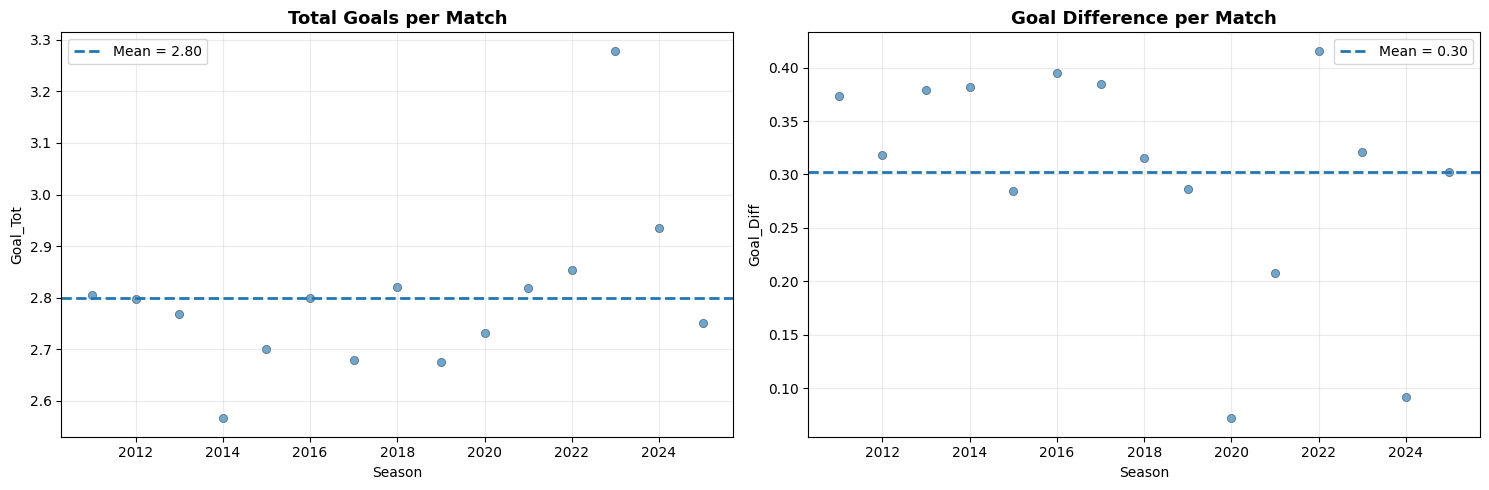

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
plots = [("Goal_Tot", "Total Goals per Match"),("Goal_Diff", "Goal Difference per Match")]

for ax, (col, title) in zip(axes, plots):

    y = df_1[col]
    mean_y = y.mean()

    ax.scatter(df_1.index,y,alpha=0.65,s=35,edgecolor="black",linewidth=0.4)

    ax.axhline(mean_y,linestyle="--",linewidth=2,label=f"Mean = {mean_y:.2f}")

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Season")
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=True)

plt.tight_layout()

A generally accepted assumption for goals in football is that they follow a poisson distribution since the goals are rare events in a given timespan. As it cab be seen below in the case of the home teams' goals the poisson distribution is very close to the observed goals. A small disagreement can be observed in the low goals value range at values 0, 1 and 2. This notebook explains the reason of this modeling failure and shows an adjustment to the poisson model for correcting for small goals' values range.

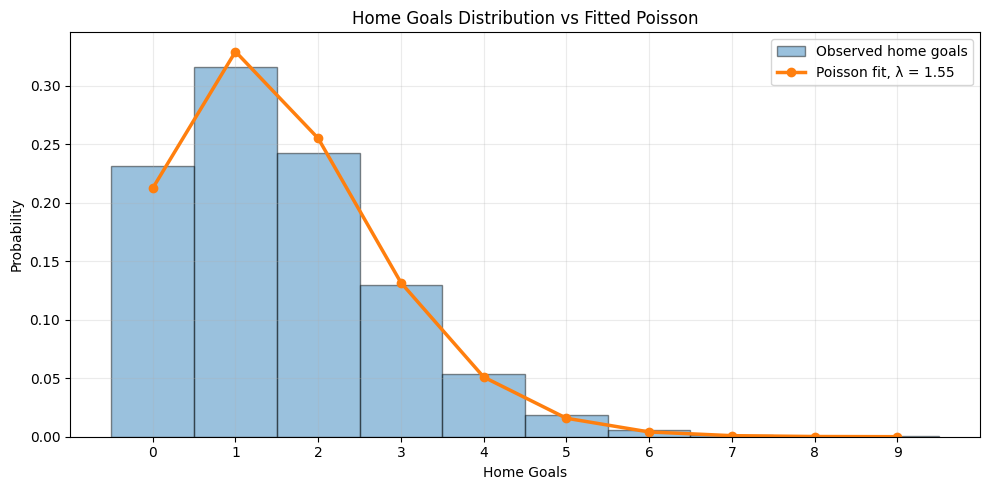

In [10]:
goals = df["HomeGoals"].dropna().astype(int)
lambda_hat = goals.mean()

x = np.arange(0, goals.max() + 1)
pmf = poisson.pmf(x, mu=lambda_hat)
bins = np.arange(goals.min() - 0.5, goals.max() + 1.5, 1)

plt.figure(figsize=(10, 5))

plt.hist(goals,bins=bins,density=True,alpha=0.45,edgecolor="black",label="Observed home goals")

plt.plot(x,pmf,marker="o",linewidth=2.5,label=f"Poisson fit, λ = {lambda_hat:.2f}")

plt.xticks(x)
plt.xlabel("Home Goals")
plt.ylabel("Probability")
plt.title("Home Goals Distribution vs Fitted Poisson")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()

## Simple Poisson Approximation for Modeling football games:

Below we can train a Poisson model based on the 2025 premier league season's data. The model is a poisson distribution . Each team has an offensive factor (team) and a deffensive factor (opponent), while there is a home factor same for all teams accounting for the home advantage. Based on the factors above for every game a poisson expected mean is calculated named λ, so the probability of scoreing k number of goals can be calculated based on the poisson distribution. Assuming that the teams' goals are independent (which is a good approximation but not true in general) the scoreline k-l for each game can be calculated by just multiplying therepsected probabilities for the home team scoring k goals and the away team scoring l goals. The Likelihood of the data is given by the probality of observing each score given the models' paramaters but for practocal reasons (due to extremely small nubers in total likelihood) the toal loglikelihood is used. The parameters of all teams and home advantage are calculated by maximiziung the total loglikelihood. The mathematical formulation is as follows:

$$ \lambda_{i} = exp(team_{i}+ opponent_{j} + \delta(home_{i}-1) \cdot home_{factor}) \\
Likelhood_{i,j} = \sum_{(k,l)} Poisson(k,lambda_{i}) \cdot Poisson(l, lambda_{j})   \\
Likelihood _{Total} = \prod_{i,j} Likelhood_{i,j} \\
LogLikelihood _{Total} = \sum_{i,j} log(Likelhood_{i,j}) $$

In [11]:
df_ex = df[(df['Season']==2025)][['HomeTeam','AwayTeam','HomeGoals','AwayGoals','FTR']]

In [12]:
df_ex['HomeTeam'].unique()

array(['Liverpool', 'Aston Villa', 'Brighton', 'Sunderland', 'Tottenham',
       'Wolves', 'Chelsea', "Nott'm Forest", 'Man United', 'Leeds',
       'West Ham', 'Man City', 'Bournemouth', 'Brentford', 'Burnley',
       'Arsenal', 'Crystal Palace', 'Everton', 'Fulham', 'Newcastle'],
      dtype=object)

In [13]:
goal_model_data = pd.concat([df_ex[['HomeTeam','AwayTeam','HomeGoals']].assign(home=1).rename(
            columns={'HomeTeam':'team', 'AwayTeam':'opponent','HomeGoals':'goals'}),
           df_ex[['AwayTeam','HomeTeam','AwayGoals']].assign(home=0).rename(
            columns={'AwayTeam':'team', 'HomeTeam':'opponent','AwayGoals':'goals'})])

poisson_model = smf.glm(formula="goals ~ home + team + opponent", data=goal_model_data,
                        family=sm.families.Poisson()).fit()
poisson_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  goals   No. Observations:                  760
Model:                            GLM   Df Residuals:                      720
Model Family:                 Poisson   Df Model:                           39
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1072.7
Date:                Mon, 27 Jul 2026   Deviance:                       762.51
Time:                        21:31:15   Pearson chi2:                     636.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1243
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -0.1575      0.231     -0.682      0.495      -0.610       0.295
team[T.Aston Villa]           -0.2157      0.179     -1.206      0.228      -0.566       0.135
team[T.Bournemouth]           -0.1755      0.177     -0.990      0.322      -0.523       0.172
team[T.Brentford]             -0.2308      0.180     -1.283      0.199      -0.583       0.122
team[T.Brighton]              -0.2931      0.183     -1.604      0.109      -0.651       0.065
team[T.Burnley]               -0.5782      0.201     -2.873      0.004      -0.973      -0.184
team[T.Chelsea]               -0.1775      0.177     -1.002      0.317      -0.525       0.170
team[T.Crystal Palace]        -0.5263      0.196     -2.680      0.007      -0.911      -0.141
team[T.Everton]               -0.3904      0.188     -2.074      0.038      -0.759      -0.021
team[T.Fulham]                -0.3894      0.188     -2.068      0.039      -0.758      -0.020
team[T.Leeds]                 -0.3426      0.186     -1.842      0.065      -0.707       0.022
team[T.Liverpool]             -0.0935      0.173     -0.540      0.590      -0.433       0.246
team[T.Man City]               0.0894      0.165      0.543      0.587      -0.233       0.412
team[T.Man United]            -0.0053      0.169     -0.031      0.975      -0.337       0.326
team[T.Newcastle]             -0.2649      0.182     -1.457      0.145      -0.621       0.091
team[T.Nott'm Forest]         -0.3683      0.187     -1.969      0.049      -0.735      -0.002
team[T.Sunderland]            -0.5051      0.195     -2.592      0.010      -0.887      -0.123
team[T.Tottenham]             -0.3622      0.187     -1.936      0.053      -0.729       0.004
team[T.West Ham]              -0.3968      0.190     -2.094      0.036      -0.768      -0.025
team[T.Wolves]                -0.9278      0.226     -4.100      0.000      -1.371      -0.484
opponent[T.Aston Villa]        0.5823      0.240      2.427      0.015       0.112       1.053
opponent[T.Bournemouth]        0.6818      0.236      2.889      0.004       0.219       1.144
opponent[T.Brentford]          0.6409      0.237      2.699      0.007       0.175       1.106
opponent[T.Brighton]           0.5149      0.243      2.122      0.034       0.039       0.991
opponent[T.Burnley]            0.9909      0.225      4.410      0.000       0.551       1.431
opponent[T.Chelsea]            0.6439      0.237      2.711      0.007       0.178       1.109
opponent[T.Crystal Palace]     0.6073      0.238      2.549      0.011       0.140       1.074
opponent[T.Everton]            0.5935      0.239      2.482      0.013       0.125       1.062
opponent[T.Fulham]             0.6133      0.238      2.574      0.010       0.146       1.080
opponent[T.Leeds]              0.7091      

The parameters of each team and home advantage have been calculated above, now a match result can be predicted based on them. Every possible scoreline compination's probability can be calculated based on the temas' expectancies and the poisson distribution, for calculating the probability of a specific result such as home win the sum of the probabilities of the respected scorelines are summed. A reasonable range 0f goals for the away and the home team is 0-10.

In [14]:
def poisson_winner_prediction(exG_home,exg_away):

  """
This function returns the predicted probabilities of results for a football game.
It is based on the independent Poisson distributions assumption.

Parameters
----------
exG_home : float
    Poisson expected goals for the home team
exg_away : float
  Poisson expected goals for the away team

Returns
-------
list :
    A list containing the prediction probabilities for each result rounded to 3 decimal points:
    [home.round, draw.round, away.round]
"""

  scores  = np.zeros((11,11))

  for i in range(0,11):
    for j in range(0,11):
      scores[i,j] = poisson.pmf(i, exG_home)*poisson.pmf(j, exg_away)

  home = np.sum(np.tril(scores,-1))
  away = np.sum(np.triu(scores,1))
  draw = np.sum(np.diag(scores))

  return [home.round(3), draw.round(3), away.round(3)]

Below the example of Liverpool against Arsenal is shown:

In [15]:
home_exG = poisson_model.predict(pd.DataFrame({'team': ['Liverpool'],'opponent': ['Arsenal'],'home': [1]})).iloc[0]

away_exG = poisson_model.predict(pd.DataFrame({'team': ['Arsenal'],'opponent': ['Liverpool'],'home': [0]})).iloc[0]

h,d,a = poisson_winner_prediction(home_exG,away_exG)
print("Liverpool vs Arsenal: Home win=",h,"Draw =" ,d,"Away win=",a)

Liverpool vs Arsenal: Home win= 0.219 Draw = 0.243 Away win= 0.537


#### Monte Carlo simulation for a full season:

Given the parameters of all teams and a function for predicting one football match, the whole season or rest of the season can be calculated by simulating all games thousands of times with a Monte Carlo simulation and extracting the teams' probabilities finishing positions, total goals scored and conceded.

In [16]:
def League_Simulation(team_names,model,sim_n = 10000,table_so_far = [],games_played = [], extra_output = 1):

  """
    Simulates the remainder of a football league season using a Poisson GLM model.

    The function runs Monte Carlo simulations of all remaining fixtures and updates
    league tables (points, goal difference, goals scored) across multiple simulated seasons.

    Parameters
    ----------
    team_names : list
        List of all team names in the league.

    model : statsmodels GLM (Poisson)
        Trained goal expectation model with formula like:
        goals ~ 0 + team + opponent (+ home or offset)

    sim_n : int, default=10000
        Number of Monte Carlo simulations per match.

    table_so_far : pandas DataFrame, optional
        Current league table with columns:
        - 'Points'
        - 'GD' (goal difference)
        - 'Tot_Goals'
        Used to initialize simulations mid-season.

    games_played : list of tuples, optional
        List of already played fixtures in the form:
        (home_team, away_team)
        These matches are excluded from simulation.

    extra_output : int, default=1
        If 1, returns full simulation outputs.
        If 0, returns only position probability table.

    Returns
    -------
    If extra_output == 1:
        points : DataFrame
            Simulated points per team across simulations.

        goal_difference : DataFrame
            Simulated goal difference per team.

        goal_total : DataFrame
            Simulated goals scored per team.

        rank_table : DataFrame
            Ranking positions per simulation (1 = best).

        position_probs : DataFrame
            Probability of each team finishing in each position.

    If extra_output == 0:
        position_probs : DataFrame
            Only finishing position probabilities.

    Notes
    -----
    - Matches are simulated using Poisson draws from expected goals.
    - Expected goals are obtained from the provided GLM model.
    - Tie-breaking includes a small adjustment using goal difference / 1000.
    - Rankings are computed per simulation column.

    """

  matchups = list(permutations(team_names, 2))
  played_set = set(games_played)

  if games_played != []:

    played_set = set(games_played)
    matchups = [g for g in matchups if g not in played_set]

    points = pd.DataFrame(
      np.zeros((len(team_names), sim_n)),
      index=team_names
    )

    points = points.add(
    table_so_far['Points'],
    axis=0,
    )

    goal_difference = pd.DataFrame(
      np.zeros((len(team_names), sim_n)),
      index=team_names
    )

    goal_difference = goal_difference.add(
    table_so_far['GD'],
    axis=0
    )

    goal_total = pd.DataFrame(
      np.zeros((len(team_names), sim_n)),
      index=team_names
    )

    goal_total = goal_total.add(
    table_so_far['Tot_Goals'],
    axis=0
    )
  else:
    points = pd.DataFrame(
      np.zeros((len(team_names), sim_n)),
      index=team_names
    )

    goal_difference = pd.DataFrame(
      np.zeros((len(team_names), sim_n)),
      index=team_names
    )

    goal_total = pd.DataFrame(
      np.zeros((len(team_names), sim_n)),
      index=team_names
    )

  for i in range(len(matchups)):

      home_team = matchups[i][0]
      away_team = matchups[i][1]

      home_exG = model.predict(pd.DataFrame({
        'team': [home_team],
        'opponent': [away_team],
        'home': [1]
      })).iloc[0]

      away_exG = model.predict(pd.DataFrame({
        'team': [away_team],
        'opponent': [home_team],
        'home': [0]
      })).iloc[0]

      home_goals = np.random.poisson(lam=home_exG, size=sim_n)
      away_goals = np.random.poisson(lam=away_exG, size=sim_n)

      goal_total.loc[home_team, :] += home_goals
      goal_total.loc[away_team, :] += away_goals

      goal_difference.loc[home_team, :] += ((home_goals - away_goals))
      goal_difference.loc[away_team, :] += ((away_goals - home_goals))

      points.loc[home_team, :] += (
        3 * (home_goals > away_goals) +
        1 * (home_goals == away_goals)
      )

      points.loc[away_team, :] += (
        3 * (away_goals > home_goals) +
        1 * (home_goals == away_goals)
      )

  points += goal_difference/1000
  rank_table = points.rank(axis=0, ascending=False, method="min")

  position_probs = (
    rank_table
    .apply(lambda row: row.value_counts(normalize=True), axis=1)
    .fillna(0)
    .sort_index(axis=1)
  )

  if extra_output == 1:
    return points, goal_difference, goal_total, rank_table,position_probs
  else:
    return position_probs

Below the 2025/2026 season is simulated given the teams' and home advantage parameters of the poisson model we fitted before. To be fair, is not exactly a simulation with predicting power but rather a fair calculation of the finishing positions of teams "replaying" the same season. For simulating the next season the same approach could be used but there is no information for the promoted teams in the previous' season sata. We will visit this problem later on for a proper simulation with predictive power before the start of a season.

In [17]:
team_names = df_ex['HomeTeam'].unique()
league_sim_res = League_Simulation(team_names,model=poisson_model,sim_n = 10000,table_so_far = [],games_played = [], extra_output = 0)
league_sim_res

,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0
Liverpool,0.0047,0.0280,0.1229,0.1380,0.1259,0.1041,0.0957,0.0748,0.0696,0.0487,0.0476,0.0414,0.0301,0.0227,0.0190,0.0139,0.0079,0.0039,0.0008,0.0003
Aston Villa,0.0015,0.0174,0.0839,0.1055,0.1035,0.1015,0.0927,0.0931,0.0752,0.0637,0.0573,0.0522,0.0446,0.0359,0.0270,0.0224,0.0128,0.0082,0.0015,0.0001
Brighton,0.0023,0.0137,0.0718,0.0997,0.1060,0.0993,0.0937,0.0862,0.0785,0.0707,0.0604,0.0519,0.0450,0.0387,0.0318,0.0262,0.0147,0.0084,0.0009,0.0001
Sunderland,0.0000,0.0004,0.0069,0.0168,0.0231,0.0339,0.0389,0.0496,0.0573,0.0646,0.0649,0.0794,0.0830,0.0947,0.0961,0.0928,0.0983,0.0712,0.0252,0.0029
Tottenham,0.0000,0.0004,0.0074,0.0130,0.0198,0.0260,0.0318,0.0389,0.0477,0.0537,0.0671,0.0774,0.0810,0.0872,0.1016,0.1069,0.1051,0.0942,0.0342,0.0066
Wolves,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0001,0.0000,0.0001,0.0003,0.0003,0.0005,0.0015,0.0031,0.0081,0.0219,0.0586,0.2614,0.6441
Chelsea,0.0015,0.0168,0.0778,0.0989,0.0997,0.1007,0.0932,0.0801,0.0783,0.0763,0.0663,0.0517,0.0454,0.0391,0.0299,0.0200,0.0140,0.0081,0.0021,0.0001
Nott'm Forest,0.0005,0.0028,0.0180,0.0299,0.0435,0.0515,0.0572,0.0660,0.0681,0.0739,0.0767,0.0784,0.0813,0.0848,0.0761,0.0722,0.0599,0.0439,0.0133,0.0020
Man United,0.0195,0.0924,0.2937,0.1766,0.1186,0.0810,0.0597,0.0427,0.0307,0.0243,0.0175,0.0177,0.0099,0.0064,0.0050,0.0018,0.0017,0.0007,0.0001,0.0000
Leeds,0.0000,0.0006,0.0083,0.0168,0.0232,0.0335,0.0464,0.0512,0.0594,0.0644,0.0748,0.0735,0.0829,0.0891,0.0960,0.0911,0.0894,0.0701,0.0250,0.0043


Below we show the probability of Arsenal finishing in each position in the league if the same season was replayed. In case of the poisson model being trained by previous season's data the following values would be the next season's prediction.

In [18]:
league_sim_res.loc['Arsenal']

,Arsenal
1.0,0.5830
2.0,0.3371
3.0,0.0569
4.0,0.0142
5.0,0.0054
6.0,0.0017
7.0,0.0007
8.0,0.0006
9.0,0.0001
10.0,0.0002


Based on the calculated matrix we can directly get the top 4, top 8, relegation, etc probabilities of any team in the league. We can see below that Tottenham's probability of relegation is close to their top 8 chances, which is expected due to the training data only consisting the last season which was a proper disaster for the Spurs. Further in this notebook there will be a better solution to such issues for considering data further back in the past.

In [19]:
print("Man City: Probability of winning the league:", league_sim_res.loc['Man City',1].round(3))
print("Liverpool: Probability finishing top 4:", league_sim_res.loc['Liverpool',1:4].sum().round(3))
print("Chelsea: Probability finishing top 4:", league_sim_res.loc['Chelsea',1:4].sum().round(3))

print("Tottenham: Probability finishing top 4:", league_sim_res.loc['Tottenham',1:8].sum().round(3))
print("Tottenham: Probability of relegation:", league_sim_res.loc['Tottenham',18:20].sum().round(3))

Man City: Probability of winning the league: 0.385
Liverpool: Probability finishing top 4: 0.294
Chelsea: Probability finishing top 4: 0.195
Tottenham: Probability finishing top 4: 0.137
Tottenham: Probability of relegation: 0.135


#### Creating derivative outright markets:

The League Simulation function has another output option (extra_output = 1) which returns all the simulations' results of points, goals, goal differences and table rankings. Based on such data other outright markets can be constructed such as total points or goals in a season for all teams or even more exotic ones by combining points, goals and ranking positions.

 From the perspective of a bettor such information can fuerther benefits. The conditional probabilities of goals and points with finishing positions can also even provide hedging probabilities for outright bets and liabillities.

In [20]:
team_names = df_ex['HomeTeam'].unique()
points, goal_difference, goal_total, rank_table,league_sim_res = League_Simulation(team_names,model=poisson_model,sim_n = 10000,table_so_far = [],games_played = [], extra_output = 1)
league_sim_res

,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0
Liverpool,0.0045,0.0277,0.1207,0.1349,0.1259,0.1111,0.0908,0.0766,0.0644,0.0559,0.0466,0.0388,0.0310,0.0244,0.0181,0.0141,0.0088,0.0044,0.0012,0.0001
Aston Villa,0.0020,0.0153,0.0810,0.1043,0.1114,0.1054,0.0990,0.0837,0.0773,0.0651,0.0612,0.0482,0.0418,0.0350,0.0273,0.0199,0.0140,0.0063,0.0018,0.0000
Brighton,0.0016,0.0139,0.0746,0.0969,0.1004,0.0996,0.0955,0.0895,0.0757,0.0696,0.0616,0.0533,0.0492,0.0395,0.0305,0.0220,0.0163,0.0091,0.0010,0.0002
Sunderland,0.0001,0.0014,0.0078,0.0172,0.0245,0.0340,0.0409,0.0462,0.0565,0.0623,0.0708,0.0819,0.0862,0.0936,0.0977,0.0895,0.0936,0.0691,0.0226,0.0041
Tottenham,0.0000,0.0005,0.0053,0.0118,0.0190,0.0267,0.0357,0.0406,0.0506,0.0585,0.0678,0.0729,0.0786,0.0926,0.1017,0.1064,0.1052,0.0900,0.0310,0.0051
Wolves,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0001,0.0004,0.0005,0.0008,0.0012,0.0039,0.0067,0.0185,0.0613,0.2602,0.6464
Chelsea,0.0021,0.0149,0.0769,0.1002,0.1017,0.0977,0.0927,0.0854,0.0786,0.0687,0.0601,0.0536,0.0485,0.0390,0.0294,0.0236,0.0164,0.0082,0.0022,0.0001
Nott'm Forest,0.0001,0.0027,0.0192,0.0298,0.0415,0.0490,0.0607,0.0675,0.0704,0.0781,0.0814,0.0803,0.0799,0.0776,0.0752,0.0720,0.0590,0.0424,0.0110,0.0022
Man United,0.0204,0.0882,0.2889,0.1828,0.1167,0.0796,0.0631,0.0452,0.0355,0.0273,0.0166,0.0129,0.0098,0.0052,0.0039,0.0017,0.0012,0.0008,0.0002,0.0000
Leeds,0.0001,0.0007,0.0082,0.0176,0.0248,0.0341,0.0382,0.0506,0.0622,0.0666,0.0705,0.0723,0.0883,0.0905,0.0923,0.0950,0.0918,0.0689,0.0230,0.0043


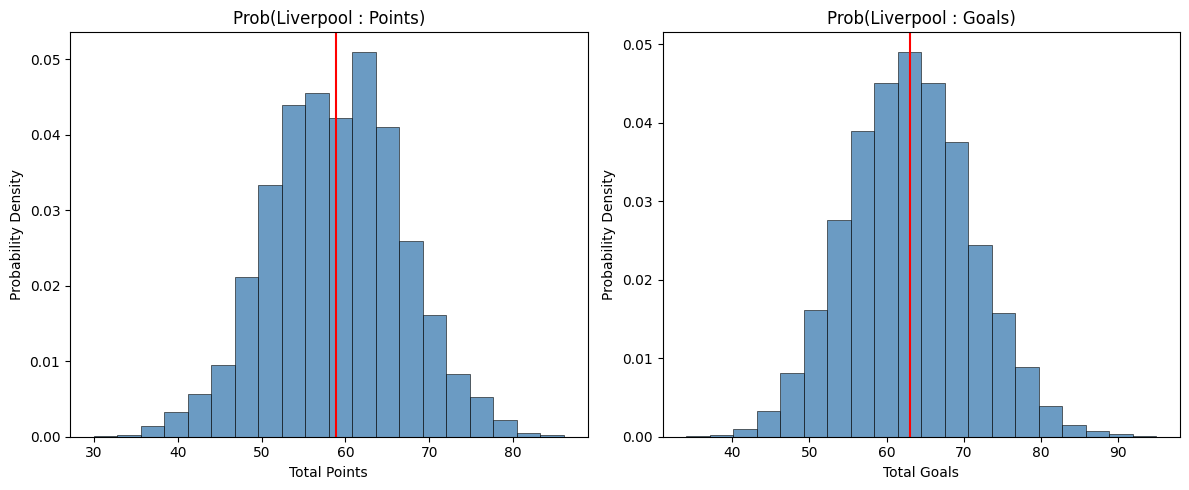

Probability of Liverpool earning more than 70 points: 0.091
Probability of Liverpool scoring more than 60 goals: 0.619


In [21]:
result = goal_total.loc['Liverpool']

fig, axes = plt.subplots(1, 2, figsize = (12,5))  # 2 rows, 2 columns

axes[0].hist(points.loc['Liverpool'],bins=20,
        density=True,
        alpha=0.8,
        color="steelblue",
        edgecolor="black",
        linewidth=0.5
        )
axes[0].axvline(x=np.mean(points.loc['Liverpool']),color = 'red')
axes[0].set_xlabel('Total Points')
axes[0].set_ylabel('Probability Density')
axes[0].set_title("Prob(Liverpool : Points)")


axes[1].hist(goal_total.loc['Liverpool'],bins=20,
        density=True,
        alpha=0.8,
        color="steelblue",
        edgecolor="black",
        linewidth=0.5
        )

axes[1].axvline(x=np.mean(goal_total.loc['Liverpool']),color = 'red')
axes[1].set_xlabel('Total Goals')
axes[1].set_ylabel('Probability Density')
axes[1].set_title("Prob(Liverpool : Goals)")


plt.tight_layout()
plt.show()

print("Probability of Liverpool earning more than 70 points:", round(sum(points.loc['Liverpool']>70)/len(points.loc['Liverpool']),3) )
print("Probability of Liverpool scoring more than 60 goals:", round(sum(goal_total.loc['Liverpool']>60)/len(goal_total.loc['Liverpool']),3) )

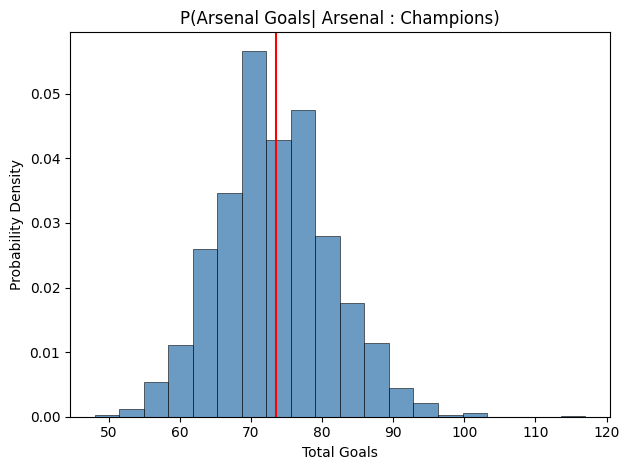

Probability of Arsenal scoring more than 80 goals given they finished first: 0.187
Probability of Liverpool scoring less than 65 goals given they finished first: 0.124


In [22]:
result = goal_total.loc['Arsenal']*(rank_table.loc['Arsenal']==1)
result = result[result!=0]

kk = plt.hist(result,bins=20,
        density=True,
        alpha=0.8,
        color="steelblue",
        edgecolor="black",
        linewidth=0.5
    )

plt.axvline(x=np.mean(result[result!=0]),color = 'red')
plt.xlabel('Total Goals')
plt.ylabel('Probability Density')
plt.title("P(Arsenal Goals| Arsenal : Champions)")

plt.tight_layout()
plt.show()

print("Probability of Arsenal scoring more than 80 goals given they finished first:", round(sum(result>80)/len(result),3) )
print("Probability of Liverpool scoring less than 65 goals given they finished first:", round(sum(result<65)/len(result),3) )

In [23]:
result = (goal_total.loc['West Ham']>45)*rank_table.loc['West Ham']
result = result[result!=0]
print("Probability of West Ham to get relegated given that they scored more than 45 goals:", round(sum(result>17)/len(result),3) )
result = (points.loc['Leeds']>35)*rank_table.loc['Leeds']
result = result[result!=0]
print("Probability of Leeds not being relegated given they earned 35 points:", round(sum(result<18)/len(result),3))

Probability of West Ham to get relegated given that they scored more than 45 goals: 0.187
Probability of Leeds not being relegated given they earned 35 points: 0.945


#### Simulating an ongoing season:

Another option in the League_Simulation function is to provide the games that took place so far in a given season that is still ongoing by providing the games' list that have been played but also the table (points,goals,goal difference) of the league so far. Below a function that returns the table so far is given:

In [24]:
def Points_Calc(df,extra_output=0):


  df = df.copy()
  df['P_H'] = 3*(df['FTR'] == 'H') + (df['FTR'] == 'D')
  df['P_A'] = 3*(df['FTR'] == 'A') + (df['FTR'] == 'D')

  home = df.groupby("HomeTeam")["P_H"].sum()
  away = df.groupby("AwayTeam")["P_A"].sum()

  tot_goals_home = df.groupby("HomeTeam")["HomeGoals"].sum()
  tot_goals_away = df.groupby("AwayTeam")["AwayGoals"].sum()

  df['G_Diff'] = df["HomeGoals"] - df["AwayGoals"]
  g_diff_home = df.groupby("HomeTeam")["G_Diff"].sum()
  g_diff_away = -df.groupby("AwayTeam")["G_Diff"].sum()


  total = home.add(away, fill_value=0).to_frame("Points")
  total["Tot_Goals"] = tot_goals_home.add(tot_goals_away, fill_value=0)
  total["GD"] = g_diff_home.add(g_diff_away, fill_value=0)

  if extra_output == 0:
    total["Points"] = total["Points"] + total["GD"] / 1000
    total["rank"] = total["Points"].rank(ascending=False, method="min")

    one_hot = pd.crosstab(
      total.index,
      total["rank"]
    ).astype(int)

    return one_hot

  else:
    return total

Below we slice the data of the previous season at the end of the calendar year of 2025, with the data before 1/1/2026 being the training data. Below the table so far is presented and the rest of the league can be simulated.

In [25]:
df_ex_2 = df[(df['Date']<datetime(2026, 1, 1)) & (df['Season']==2025)]
table_so_far = Points_Calc(df_ex_2,extra_output=1)
table_so_far.sort_values(by = 'Points', ascending = False)

,Points,Tot_Goals,GD
HomeTeam,,,
Arsenal,45,37.0,25.0
Man City,40,43.0,26.0
Aston Villa,39,30.0,7.0
Liverpool,32,30.0,4.0
Man United,30,33.0,4.0
Chelsea,30,32.0,11.0
Everton,28,20.0,0.0
Sunderland,28,20.0,2.0
Newcastle,26,26.0,2.0


By the Monte Carlo simulation's results Arsenal was already a big favourite with 71.8% to win the league with Man City following with 27.75%.Both Arsenal and Man City losing the losing accounted fot around 0.45%.
On the other side the relegation battle seemed already lost for Wolves with almost 100% getting relegated with Burnley following close with 87.79%. Next candidate for getting relegated was predicted to be West Ham with 69.12%. The biggest outliers were Man United, Bournemoth and Tottenham in terms of finishing positions, Tottenham probability of relegated was 0.3%! But overall the results seem reasonable for the majority of the teams.


In [26]:
team_names = df_ex_2['HomeTeam'].unique()
goal_model_data = pd.concat([df_ex_2[['HomeTeam','AwayTeam','HomeGoals']].assign(home=1).rename(
            columns={'HomeTeam':'team', 'AwayTeam':'opponent','HomeGoals':'goals'}),
           df_ex_2[['AwayTeam','HomeTeam','AwayGoals']].assign(home=0).rename(
            columns={'AwayTeam':'team', 'HomeTeam':'opponent','AwayGoals':'goals'})])

poisson_model_ex = smf.glm(formula="goals ~ home + team + opponent", data=goal_model_data,
                        family=sm.families.Poisson()).fit()

games_played = list(df_ex_2[["HomeTeam", "AwayTeam"]].itertuples(index=False, name=None))

points_2, goal_difference_2, goal_total_2, rank_table_2,league_sim_2 = League_Simulation(team_names,model=poisson_model_ex,sim_n = 10000,table_so_far = table_so_far,games_played = games_played, extra_output = 1)

In [27]:
league_sim_2

,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0
Arsenal,0.7170,0.2713,0.0115,0.0002,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Aston Villa,0.0074,0.0759,0.7101,0.1371,0.0407,0.0168,0.0071,0.0025,0.0014,0.0006,0.0003,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
Bournemouth,0.0000,0.0000,0.0002,0.0010,0.0020,0.0046,0.0078,0.0121,0.0209,0.0313,0.0433,0.0639,0.0910,0.1501,0.2661,0.2282,0.0625,0.0128,0.0022,0.0000
Brentford,0.0000,0.0001,0.0057,0.0375,0.0669,0.0791,0.0899,0.1014,0.0971,0.1020,0.1004,0.0922,0.0910,0.0737,0.0464,0.0147,0.0019,0.0000,0.0000,0.0000
Brighton,0.0000,0.0000,0.0021,0.0167,0.0304,0.0464,0.0648,0.0786,0.0885,0.1036,0.1069,0.1125,0.1157,0.1125,0.0805,0.0360,0.0043,0.0005,0.0000,0.0000
Burnley,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0001,0.0004,0.0029,0.0161,0.0987,0.2660,0.6061,0.0097
Chelsea,0.0001,0.0011,0.0602,0.2315,0.2166,0.1478,0.1050,0.0740,0.0564,0.0389,0.0299,0.0198,0.0103,0.0063,0.0018,0.0003,0.0000,0.0000,0.0000,0.0000
Crystal Palace,0.0000,0.0000,0.0043,0.0258,0.0473,0.0706,0.0842,0.0912,0.0967,0.1034,0.1037,0.1046,0.1043,0.0844,0.0541,0.0226,0.0023,0.0005,0.0000,0.0000
Everton,0.0000,0.0000,0.0032,0.0229,0.0428,0.0678,0.0778,0.0937,0.0962,0.1086,0.1068,0.1034,0.1063,0.0919,0.0550,0.0213,0.0022,0.0001,0.0000,0.0000
Fulham,0.0000,0.0001,0.0026,0.0206,0.0361,0.0523,0.0692,0.0788,0.0894,0.0972,0.0983,0.1125,0.1135,0.1094,0.0802,0.0353,0.0040,0.0004,0.0001,0.0000


Below we can compare the predicted expected points and goals for the whole league for all teams with the final league table results. In detail, the redicted minus the observed values are presented, as it can be shown in terms of points the biggest disapointments ate Tottenham and Chelsea, with Crystal Palace and Aston Villa following close. For the latter two this disapoijnting number of points in league could be affected by their lack of interesting in the league games early on since they reached their targets early and they focused more in their European games. Contrary, the biggest positive surprises were Man United and Bournemouth by far with both managing to get a European ticket for the next season.

In [28]:
df_sim_upd = points_2.mean(axis = 1)
df_sim_upd = pd.concat([points_2.mean(axis = 1), goal_total_2.mean(axis = 1)], axis=1)
df_sim_upd.rename(columns={df_sim_upd.columns[0]: 'Points',df_sim_upd.columns[1]: 'Tot_Goals'},inplace = True)


table_end_season = Points_Calc(df[df['Season']==2025],extra_output=1)
table_end_season.drop(columns = 'GD',inplace = True)
table_end_season.sort_values(by = 'Points', ascending = False)
table_eval = table_end_season.sub(df_sim_upd)
table_eval.rename(columns={'Points':'Points Diff','Tot_Goals':'Goals Diff'}, inplace = True)
table_eval['Observed Points'] = table_end_season['Points']
table_eval.sort_values(by = 'Observed Points',ascending = False)

,Points Diff,Goals Diff,Observed Points
HomeTeam,,,
Arsenal,-2.728476,-3.9323,85
Man City,-5.076294,-12.0899,78
Man United,13.938799,3.9449,71
Aston Villa,-7.530757,-6.3497,65
Liverpool,-2.823153,-0.6883,60
Bournemouth,11.280797,1.2491,57
Sunderland,-2.629587,0.0905,54
Brentford,-1.527237,-3.1414,53
Brighton,0.742995,-4.4952,53


#### Home Advantage:

A reasonable assumption is that the home advantage is not changing by a lot year on year since the football remains the same sport and only 3 teams are changing yearly. Overall the home advantage is decreasing but over many years due to advancements of professional footbal but in much slower pace https://blog.engora.com/2025/07/vanishing-home-field-advantage-in.html .The only potential fact against this assumption is the introduction of VAR which has to be tested.

Another issue with modeling the football result and handlling the home advantage as a free parameter to be fitted it could varries by a lot on different year which has an important effect on teams' strength factors and outputting misleading results. It would be prefferable to have a fixed value based on a long term average value.

In [29]:
home_adv = np.zeros(len(df['Season'].unique()))
home_std = np.zeros(len(df['Season'].unique()))
season_sim = np.zeros(len(df['Season'].unique()))
k = 0
LogLikel = 0

for i in df['Season'].unique():
  df_ex = df[df['Season']==i][['HomeTeam','AwayTeam','HomeGoals','AwayGoals']].copy()
  goal_model_data = pd.concat([df_ex[['HomeTeam','AwayTeam','HomeGoals']].assign(home=1).rename(
            columns={'HomeTeam':'team', 'AwayTeam':'opponent','HomeGoals':'goals'}),
           df_ex[['AwayTeam','HomeTeam','AwayGoals']].assign(home=0).rename(
            columns={'AwayTeam':'team', 'HomeTeam':'opponent','AwayGoals':'goals'})])

  poisson_model_hm = smf.glm(formula="goals ~ home + team + opponent", data=goal_model_data,
                        family=sm.families.Poisson()).fit()

  home_adv[k] = poisson_model_hm.params.home
  home_std[k] = poisson_model_hm.bse.loc['home']
  season_sim[k] = i
  LogLikel += poisson_model_hm.llf
  k += 1

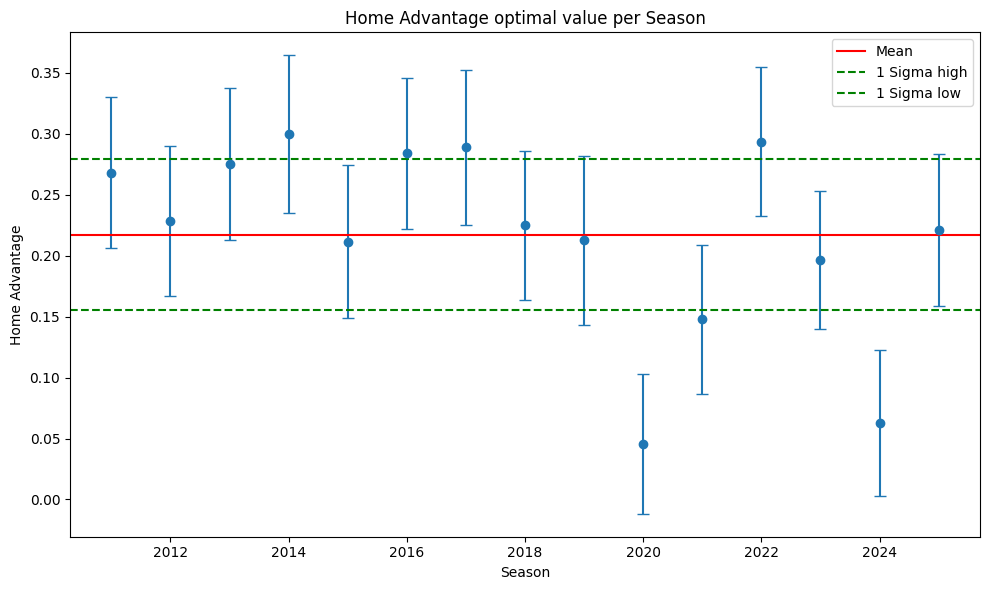

In [30]:
plt.figure(figsize=(10, 6))

plt.errorbar(
    x=season_sim,
    y=home_adv,
    yerr=home_std,
    fmt='o',
    capsize=4
)

home_adv_overall = np.mean(home_adv)
home_adv_std_overall = np.sqrt(np.sum(home_std**2)/len(home_std))

plt.axhline(y=home_adv_overall, color='r', linestyle='-',label = 'Mean')
plt.axhline(y=home_adv_overall-home_adv_std_overall, color='g', linestyle='--',label = '1 Sigma high')
plt.axhline(y=home_adv_overall+home_adv_std_overall, color='g', linestyle='--',label = '1 Sigma low')

plt.xlabel("Season")
plt.ylabel("Home Advantage")
plt.title("Home Advantage optimal value per Season")
plt.legend()
plt.tight_layout()
plt.show()

In the plot above the average home advantage mean value was calculated based on all the years' parameters' values but is is obvious that the years of 2020,2021 and 2024 are far from the one sigma area of the mean. A huge impact for the seasons 2020 and 2021 is the Covid restrictions changing the home advantage a lot since there were no spectators and even when there were fans there were many restrictions limiting the fans' impact. So overall these years are a combination of the VAR and the Covid effects so they will be ignored. The 2024 extremely low home advantage value doesn't have a clear explanation so further analysis is needed, since the years 2022,2023 and 2025 had averages within the 1 sigma range of the overall mean although VAR was in effect.

For the reasons explained above we have to test if such outliers as 2024 are just random effects at 5% significance level using the average value prior to 2019 and the 2022,2023 and 2025 years compared to the most extreme outlier value.

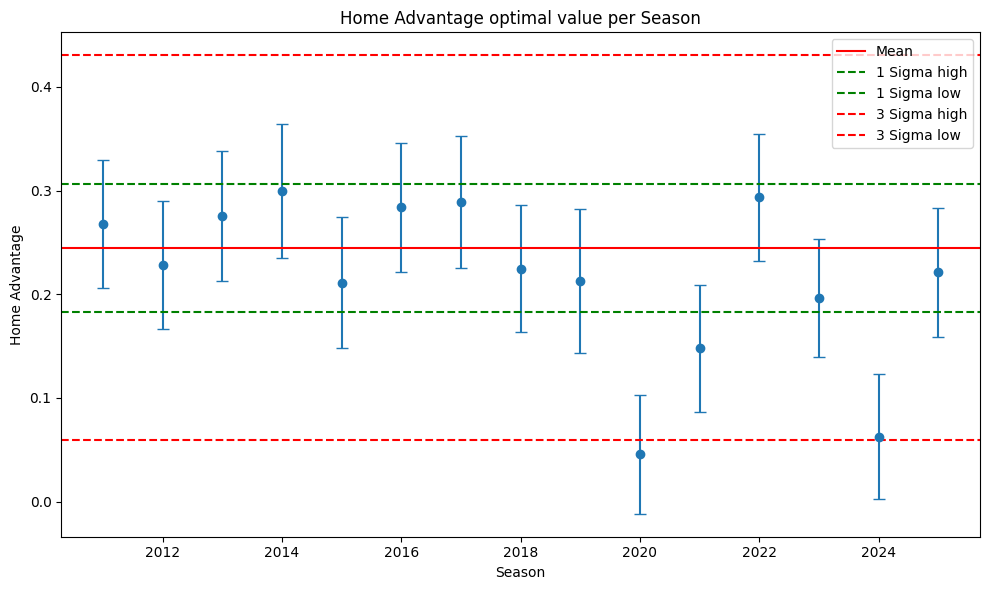

P-value of home advantage of 2024 belonging to the home advantage mean prior to 2019: 0.11623


In [31]:
from scipy.stats import norm

plt.figure(figsize=(10, 6))

plt.errorbar(
    x=season_sim,
    y=home_adv,
    yerr=home_std,
    fmt='o',
    capsize=4
)

hom_adv_slice = home_adv[np.isin(season_sim ,np.array([2019,2020,2024]))==False]
home_std_slice = home_std[np.isin(season_sim ,np.array([2019,2020,2024]))==False]
home_adv_overall = np.mean(hom_adv_slice)
home_adv_std_overall = np.sqrt(np.sum(home_std_slice**2)/len(home_std_slice))

plt.axhline(y=home_adv_overall, color='r', linestyle='-',label = 'Mean')
plt.axhline(y=home_adv_overall-home_adv_std_overall, color='g', linestyle='--',label = '1 Sigma high')
plt.axhline(y=home_adv_overall+home_adv_std_overall, color='g', linestyle='--',label = '1 Sigma low')

plt.axhline(y=home_adv_overall-3*home_adv_std_overall, color='r', linestyle='--',label = '3 Sigma high')
plt.axhline(y=home_adv_overall+3*home_adv_std_overall, color='r', linestyle='--',label = '3 Sigma low')
plt.xlabel("Season")
plt.ylabel("Home Advantage")
plt.title("Home Advantage optimal value per Season")
plt.legend()
plt.tight_layout()
plt.show()

p_value = 2 * (1 - norm.cdf(abs((home_adv_overall-hom_adv_slice.min())/home_adv_std_overall)))
print("P-value of home advantage of 2024 belonging to the home advantage mean prior to 2019:",round(p_value,5))

It is clear from the plot that the 2024 home advantage parameter value is inside the 3 sigma area of the home advantage mean. Assuming that the home advantage doesn't change and the 2024 value is a random variable following the same distribution we get a p value of 0.116 so the null hypothesis cannot be rejected and the mean home advantage can be fixed to the mean calculated above based on the given data.

But visually it there is a trend on home advantage getting smaller so the home advantage overall value will be revisited in this Notebook.

## Dixon-Coles model:

The main model that is used for predicting football games is the Dixon-Coles model published as https://www.ajbuckeconbikesail.net/wkpapers/Airports/MVPoisson/soccer_betting.pdf, which introduced a time decay component for including results further in the past weighted by the time difference from the current estimation and an empirical correction in the correct score matrix. in the bivariate poisson model shown before. The time decay component is an obvious correction but the score matrix correction is a fundamental contrantiction of the fundamental assumption in the BP model of teams' goals independence. It has been observed that at the low scoring area of the matrix with scores 0-0.1-0, 0-1, 1-1 the observed probability is higher than the estimated value by the BP model and thus a correction is applied based on observations.

#### Time Decay:

It is reasonable to think that the further in the past an event took place the less important is for evaluating the strength of a team. Especially in football it is observed often teams to have large fluctuations in terms of performance within a year so recent events are more representantive on how a team is going to play next week.
 On the other hand, taking into consideration only the games within a given season is an approach that lacks information for the strength of a team during the last season but also even further. Teams which are performing greatly in the last 5 years might have a bad start in a season, without considering the previous season their strength would be unreasonably low. A way for quantifying the importance of games based on how many days before the day of the model calculating the parameters is by introducing a weight to each game that affects the Likelihood function:

 $$ φ(ξ,t) = e^{(ξ \cdot (t_{recent} - t_{i,j}))} , t_{recent} = 0 \\
 Likelihood_{Total_{new}} = \prod_{i,j} Likelihood_{Poisson_{i,j}} * φ(ξ,t_{i,j}) $$

 The new total likelihood function is changing with time supressing the contribution of past events more and more as time passes in contrast to the previous model where the likelihood was affected equally by all events.

Text(0.5, 1.0, 'Time Decay Weight')

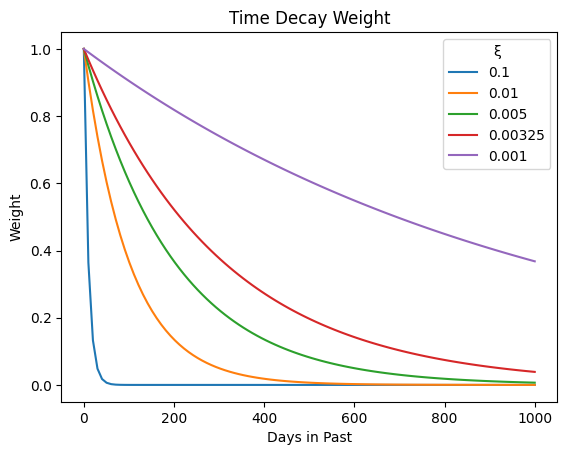

In [32]:
plt.plot(np.linspace(0,1000,100), np.exp(-0.1*np.linspace(0,1000,100)))
plt.plot(np.linspace(0,1000,100), np.exp(-0.01*np.linspace(0,1000,100)))
plt.plot(np.linspace(0,1000,100), np.exp(-0.005*np.linspace(0,1000,100)))
plt.plot(np.linspace(0,1000,100), np.exp(-0.00325*np.linspace(0,1000,100)))
plt.plot(np.linspace(0,1000,100), np.exp(-0.001*np.linspace(0,1000,100)))

plt.legend(['0.1','0.01','0.005','0.00325','0.001'],title = 'ξ')
plt.title('Time Decay Weight for different ξ')
plt.xlabel('Days in Past')
plt.ylabel('Weight')
plt.title('Time Decay Weight')

The target of modeling the premier league data is not for explanatory reason but for prediction of future events. For this reason a function for testing the predictive power of any model is needed based on either thr results or scores predictions of out of sample events. With the same reasoning as before by summing the total loglikelihood of results and scores the predictive power can be measured.

In [33]:
def log_likl_eval(model,matches_results,matches_scores = [],matches = []):

  log_prob_sum = 0
  log_prob_scores_sum = 0

  for i in range(len(matches)):

      home_team = matches[i][0]
      away_team = matches[i][1]

      home_exG = model.predict(pd.DataFrame({'team': [home_team],'opponent': [away_team],'home': [1]})).iloc[0]
      away_exG = model.predict(pd.DataFrame({'team': [away_team],'opponent': [home_team],'home': [0]})).iloc[0]

      pred_result = poisson_winner_prediction(home_exG,away_exG)
      log_prob_sum += np.log(pred_result[0]*(matches_results[i] == 'H')+pred_result[1]*(matches_results[i] == 'D')+pred_result[2]*(matches_results[i] == 'A'))
      log_prob_scores_sum += np.log(poisson.pmf(matches_scores[i][0], home_exG)*poisson.pmf(matches_scores[i][1], away_exG))

  return log_prob_sum, log_prob_scores_sum

The ξ variable of the time decay function can be fitted with the target being the calculation of its optimal value based on the results and scorelines loglikelihood. Based on the Dixon-Coles model a reasonable range of this metric is within [0,0.01] if the tinme variable is days.

In [34]:
no_xi_values = 20
xi_values = np.linspace(0,0.01,no_xi_values)
log_prob_resu_xi = np.zeros(no_xi_values)
log_prob_scores_xi = np.zeros(no_xi_values)
l = 0
for k in xi_values:
  for i in range(2022, df['Season'].max()+1):
    df_ex = df[(df['Season']<=i)][['HomeTeam','AwayTeam','HomeGoals','AwayGoals','Date','FTR']].copy()
    for j in range(0,45):

      df_slice_next_games = df_ex[(df_ex['Date']>datetime(i,9,1)+timedelta(days=7*j)) & (df_ex['Date']<datetime(i,9,1)+timedelta(days=7*j+7))].copy()
      games_to_be_played = list(df_slice_next_games[["HomeTeam", "AwayTeam"]].itertuples(index=False, name=None))

      if games_to_be_played != []:
        df_ex2 = df_ex[df_ex['Date']<datetime(i,9,1)+timedelta(days=7*j)].copy()
        df_ex2['time_weights'] = np.exp(k*(df_ex2['Date']-df_ex2['Date'].max()).dt.days)

        goal_model_data = pd.concat([df_ex2[['HomeTeam','AwayTeam','HomeGoals','time_weights']].assign(home=1).rename(
            columns={'HomeTeam':'team', 'AwayTeam':'opponent','HomeGoals':'goals'}),
           df_ex2[['AwayTeam','HomeTeam','AwayGoals','time_weights']].assign(home=0).rename(
            columns={'AwayTeam':'team', 'HomeTeam':'opponent','AwayGoals':'goals'})])

        poisson_model_time_dec = smf.glm(formula="goals ~ 0 + home + team + opponent", data=goal_model_data,freq_weights=goal_model_data['time_weights'],
                                         family=sm.families.Poisson()).fit()

        log_prob_eval = log_likl_eval(poisson_model_time_dec,df_slice_next_games["FTR"].values,matches_scores = df_slice_next_games[["HomeGoals", "AwayGoals"]].values,matches = games_to_be_played)
        log_prob_resu_xi[l] += log_prob_eval[0]
        log_prob_scores_xi[l] += log_prob_eval[1]
  l+=1

Best ξ value based on results' Likelihood: 0.00263
Best ξ value based on scores' Likelihood: 0.00263
Highest value of scores' Likelihood: -3723.69


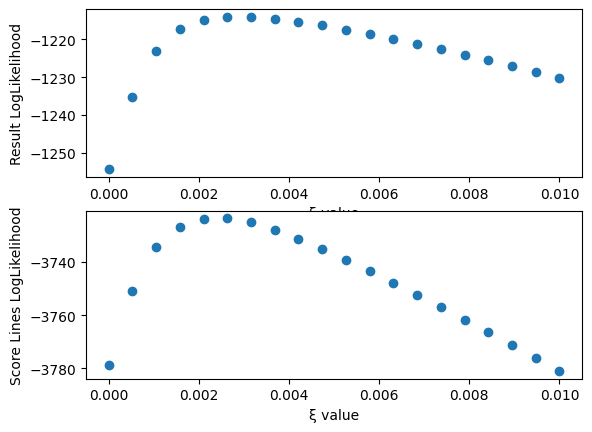

In [35]:
fig, ax = plt.subplots(2)
xi_optimal_DC = xi_values[np.argmax(log_prob_scores_xi)]

ax[0].scatter(xi_values,log_prob_resu_xi)
ax[0].set_xlabel('ξ value')
ax[0].set_ylabel('Result LogLikelihood')

ax[1].scatter(xi_values,log_prob_scores_xi)
ax[1].set_xlabel('ξ value')
ax[1].set_ylabel('Score Lines LogLikelihood')

print("Best ξ value based on results' Likelihood:",np.around(xi_values[np.argmax(log_prob_resu_xi)],5))
print("Best ξ value based on scores' Likelihood:",np.round(xi_values[np.argmax(log_prob_scores_xi)],5))
log_prob_scores_xi_best = np.round(np.max(log_prob_scores_xi),2)
print("Highest value of scores' Likelihood:",log_prob_scores_xi_best)

max_likel_DC_SC = log_prob_scores_xi_best
max_likel_DC_RESU = np.round(np.max(log_prob_resu_xi),2)

#### Insights on Home Advantage and League Competitiveness:

Now that there is an optiman ξ value the maodel can be trained over the whole dataset getting insights for teams' strengths and the home advantage over the years in a continous manner using information of the previous seasons as well:

In [36]:
home_adv_timedec = []
home_std_timedec = []
week_sim = []
season_week_sim = []
params = []

k=0
for i in range(df['Season'].min()+1, df['Season'].max()+1):
  df_ex = df[(df['Season']<=i)][['HomeTeam','AwayTeam','HomeGoals','AwayGoals','Date']].copy()
  for j in range(0,40):
    df_ex2 = df_ex[df_ex['Date']<datetime(i,9,1)+timedelta(days=7*j)].copy()
    df_ex2['time_weights'] = np.exp(xi_optimal_DC*(df_ex2['Date']-df_ex2['Date'].max()).dt.days)

    goal_model_data = pd.concat([df_ex2[['HomeTeam','AwayTeam','HomeGoals','time_weights']].assign(home=1).rename(
            columns={'HomeTeam':'team', 'AwayTeam':'opponent','HomeGoals':'goals'}),
           df_ex2[['AwayTeam','HomeTeam','AwayGoals','time_weights']].assign(home=0).rename(
            columns={'AwayTeam':'team', 'HomeTeam':'opponent','AwayGoals':'goals'})])

    goal_model_data["team"] = goal_model_data["team"].astype("category")
    goal_model_data["team"] = goal_model_data["team"].cat.reorder_categories(
    ["Blackburn"] + [t for t in goal_model_data["team"].unique() if t != "Blackburn"],
    ordered=True
    )

    goal_model_data["opponent"] = goal_model_data["opponent"].astype("category")
    goal_model_data["opponent"] = goal_model_data["opponent"].cat.reorder_categories(
    ["Blackburn"] + [t for t in goal_model_data["opponent"].unique() if t != "Blackburn"],
    ordered=True
    )

    poisson_model = smf.glm(formula="goals ~ 0 + home + team + opponent", data=goal_model_data,freq_weights=goal_model_data['time_weights'],
                        family=sm.families.Poisson()).fit()


    params.append(poisson_model.params)
    home_adv_timedec.append(poisson_model.params.home)
    home_std_timedec.append(poisson_model.bse.loc['home'])
    week_sim.append((i%2012-1)*52+j)
    season_week_sim.append(i)
    k += 1

home_adv_timedec = np.array(home_adv_timedec)
home_std_timedec = np.array(home_std_timedec)
week_sim = np.array(week_sim)
season_week_sim = np.array(season_week_sim)

The following code just gets the teams parameters out of the list we used to capture them before:

In [37]:
import copy
params_copy = copy.deepcopy(params)

l = -1
std_att = []
att = []
attack_params_sel = []
mean_att = []
selected_teams = ['Arsenal','Liverpool','Man City', 'Chelsea']

for k in range(df['Season'].min()+1, df['Season'].max()+1):
  team_names = df[df['Season']==k]['HomeTeam'].unique()
  l +=1

  for i in range(0,40):
    params_copy[i+l*40].index = params_copy[i+l*40].index.str.replace(
    r"^team\[(.*)\]$",
    r"\1",
    regex=True
    )

    teams_present = np.intersect1d(team_names, params_copy[i+l*40].index)

    std_att.append(np.std(params_copy[i+l*40].loc[teams_present]))
    att.append(params_copy[i+l*40].loc[teams_present].values)
    mean_att.append(np.mean(params_copy[i+l*40].loc[teams_present]))
    attack_params_sel.append(params_copy[i+l*40].loc[selected_teams].values)


In [38]:
params_copy = copy.deepcopy(params)
l = -1
std_def = []
def_params_sel = []
deff = []
mean_def = []
selected_teams = ['Arsenal','Liverpool','Man City', 'Chelsea']

for k in range(df['Season'].min()+1, df['Season'].max()+1):
  team_names = df[df['Season']==k]['HomeTeam'].unique()
  l +=1

  for i in range(0,40):

    params_copy[i+l*40].index = params_copy[i+l*40].index.str.replace(
    r"^opponent\[T.(.*)\]$",
    r"\1",
    regex=True
    )

    teams_present = np.intersect1d(team_names, params_copy[i+l*40].index)
    std_def.append(np.std(params_copy[i+l*40].loc[teams_present]))
    deff.append(params_copy[i+l*40].loc[teams_present].values)
    mean_def.append(np.mean(params_copy[i+l*40].loc[teams_present]))
    def_params_sel.append(params_copy[i+l*40].loc[selected_teams].values)

In [39]:
strength_std = np.zeros(len(att))
for i in range(len(att)):
   strength_std[i] = np.std(np.exp(mean_def[i] + att[i]) - np.exp(mean_att[i] + deff[i]))



Below the team strength of 4 of the strongest team in Premier League over the last years is shown as the goal difference based on the model against the average team over the time span of the last 15 season. It is more than clear than Man City Dominated the league almost exclusively (with an excemption at the of the 2015 season)until the end of the middle of the 2023 season. Liverpool was also very strong and consistant as second strongest team in the period 2017-2022 while the recent collapse over the 2025 season is obvious. Arsenal was never the best team or even very close until the 2024 season and after managing to be slightly better than Man City over the 2025 season. Chelsea's strength on the other hand is fluctating much more far away from being the strongest team of the league.

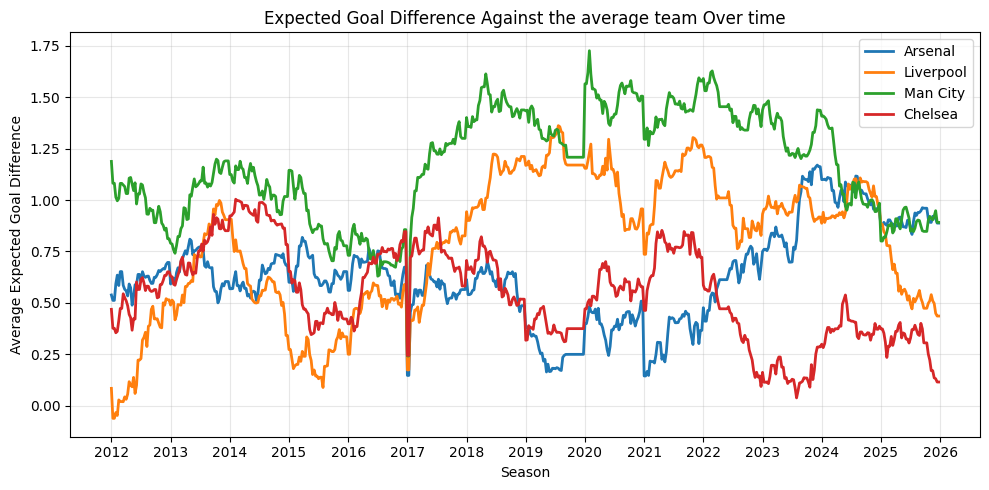

In [40]:
mean_def = np.array(mean_def)
attack_params_sel = np.array(attack_params_sel)
mean_att = np.array(mean_att)
def_params_sel = np.array(def_params_sel)

plt.figure(figsize=(10, 5))

top_teams_strength = np.zeros((len(mean_att),4))
for i in range(4):
    plt.plot(
        np.exp(mean_def + attack_params_sel[:, i]) - np.exp(mean_att + def_params_sel[:, i]),
        linewidth=2
    )
    top_teams_strength[:,i] = np.exp(mean_def + attack_params_sel[:, i]) - np.exp(mean_att + def_params_sel[:, i])

plt.legend(selected_teams)
plt.xlabel("Season")
plt.ylabel("Average Expected Goal Difference")
plt.title("Expected Goal Difference Against the average team Over time")

plt.grid(alpha=0.3)
years = np.arange(2012, 2027, 1)
tick_positions = (years - 2012) * 40
plt.xticks(tick_positions, years)

plt.tight_layout()

Another interesting prespective over the league is the competitiveness over the years. A way to find a metric for quantifying how competitive is the league is by calculating the defensive and the attacking factors' standard deviation overall and then handling them as a sum of variables for getting the overall std combining the information from both of them, We can define a Competitiveness index as the inverse of the overall coefficients std, being zero when the league is the least competitive (σ ->infinity) or increasing as the σ overall gets smaller (asympotically reaching infinity).

$$ σ_{attack} = \sqrt{E[(AttackFactors-μ_{AttackFactors})^{2}]} \\
σ_{deffense} = \sqrt{E[(DeffenseFactors-μ_{DeffenseFactors})^{2}]}  \\
σ_{overall} = \sqrt{σ_{attack}^{2}+σ_{deffense}^{2}} \\
Competitiveness_{index} = \frac{1}{σ_{overall}}$$

The biggest the differense between the attack factors (and similarly the deffense ones) of all the teams in a league the less competitive a league is, the best way to cature that is by the factors' variance or standard deviation.

There many fluctuations for the competitiveness index over the years with some clear trends to be the less competitive years during the era of the Man City and Liverpool domination (2019-2025) and the last two seasons being more competitive than ever showcasing the advancements of the smaller clubs recently.

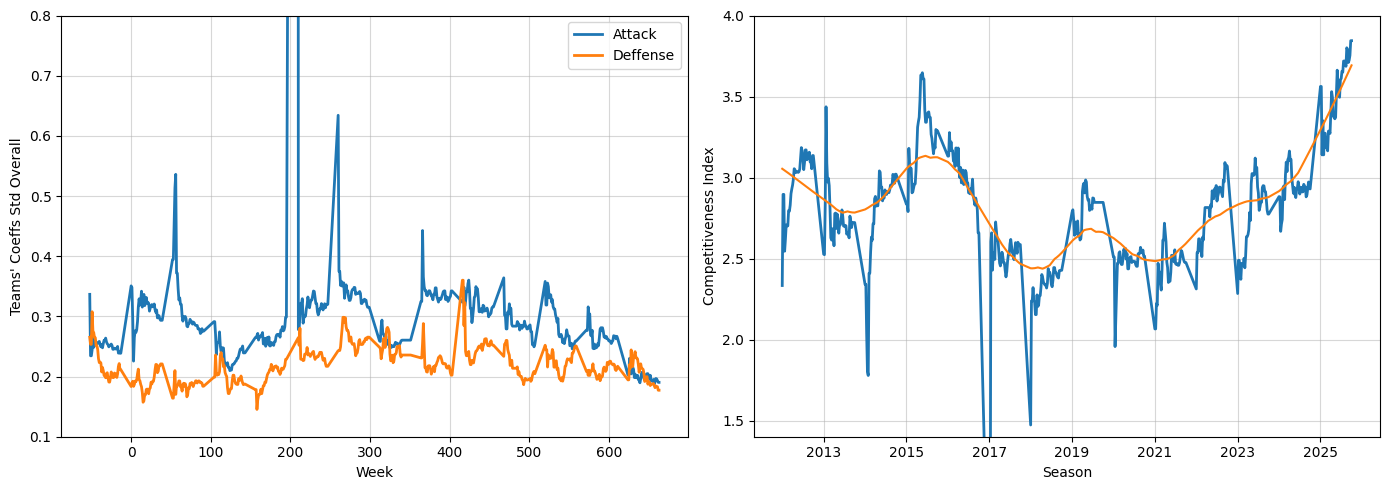

In [41]:
from statsmodels.nonparametric.smoothers_lowess import lowess

std_def = np.array(std_def)
std_att = np.array(std_att)

fig, axes = plt.subplots(1,2, figsize = (14,5))

axes[0].plot(week_sim,std_att,linewidth=2)
axes[0].plot(week_sim[std_def<1],std_def[std_def<1],linewidth=2)

axes[0].set_xlabel('Week')
axes[0].set_ylabel('Teams\' Coeffs Std Overall')
axes[0].legend(['Attack','Deffense'])
axes[0].grid(alpha=0.5)
axes[0].set_ylim(0.1,0.8)

axes[1].plot(week_sim,np.sqrt(1/(std_def**2+std_att**2)),linewidth=2)
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Competitiveness Index')

years = np.arange(2013, 2027, 2)
tick_positions = (years - 2013) * 52
axes[1].set_xticks(tick_positions, years)
axes[1].grid(alpha=0.5)
axes[1].set_ylim(1.4,4)

low = sm.nonparametric.lowess
smoothed_compind = lowess(np.sqrt(1/(std_def**2+std_att**2)), week_sim, frac=0.2)
axes[1].plot(smoothed_compind[:,0],smoothed_compind[:,1])


plt.tight_layout()

A closer look is needed in order to understand how the Competitiveness index, by visualizing its relation with the points and goals of the teams across the league. The winner, top4 (4rth team), top 10 (10th) and relegated zone (18th) teams are picked for every year and they are plotted against the competitiveness index at the end of that season and fitting a linear regression for each case. The seasons selected are the 2021 and onwards for testing the post covid football where the home advantage and the way of football overall has changed.

By the plots and the R squared metric the Competitiveness index can explain a very large % of the variance of the winner and top 4 points and goals showing that this index is measuring how competitive is the top end of the league. The bottom and Relegation zone teams (17th) seems to have low to none correlation with the index showing that the index is explaining much better the high end of the table. That bevavoir is expected due to the most of the coefficients variance contributions come from the strongest teams of the league with a much higher attack and lower deffence coefficients while the low table teams do not show large differences.

In [42]:
no_years = 5
pos_m = smoothed_compind[np.arange(15-no_years,15)*40-1,1]
winner_p = np.zeros(no_years)
top_4_p = np.zeros(no_years)
relegation_p = np.zeros(no_years)
bottom_p = np.zeros(no_years)

winner_g = np.zeros(no_years)
top_4_g = np.zeros(no_years)
relegation_g = np.zeros(no_years)
bottom_g = np.zeros(no_years)

k=0
for i in range(2025-no_years+1,2025+1):
  pos_sm = ((i%2012-1)*52)

  df_ex_3 = df[df['Season']==i]
  table_so_far = Points_Calc(df_ex_3,extra_output=1)
  table_so_far = table_so_far.sort_values(by = 'Points', ascending = False)
  winner_p[k] = table_so_far['Points'].iloc[0]
  top_4_p[k] = table_so_far['Points'].iloc[3]
  relegation_p[k] = table_so_far['Points'].iloc[17]
  bottom_p[k] = table_so_far['Points'].iloc[19]

  winner_g[k] = table_so_far['Tot_Goals'].iloc[0]
  top_4_g[k] = table_so_far['Tot_Goals'].iloc[3]
  relegation_g[k] = table_so_far['Tot_Goals'].iloc[17]
  bottom_g[k] = table_so_far['Tot_Goals'].iloc[19]

  k += 1

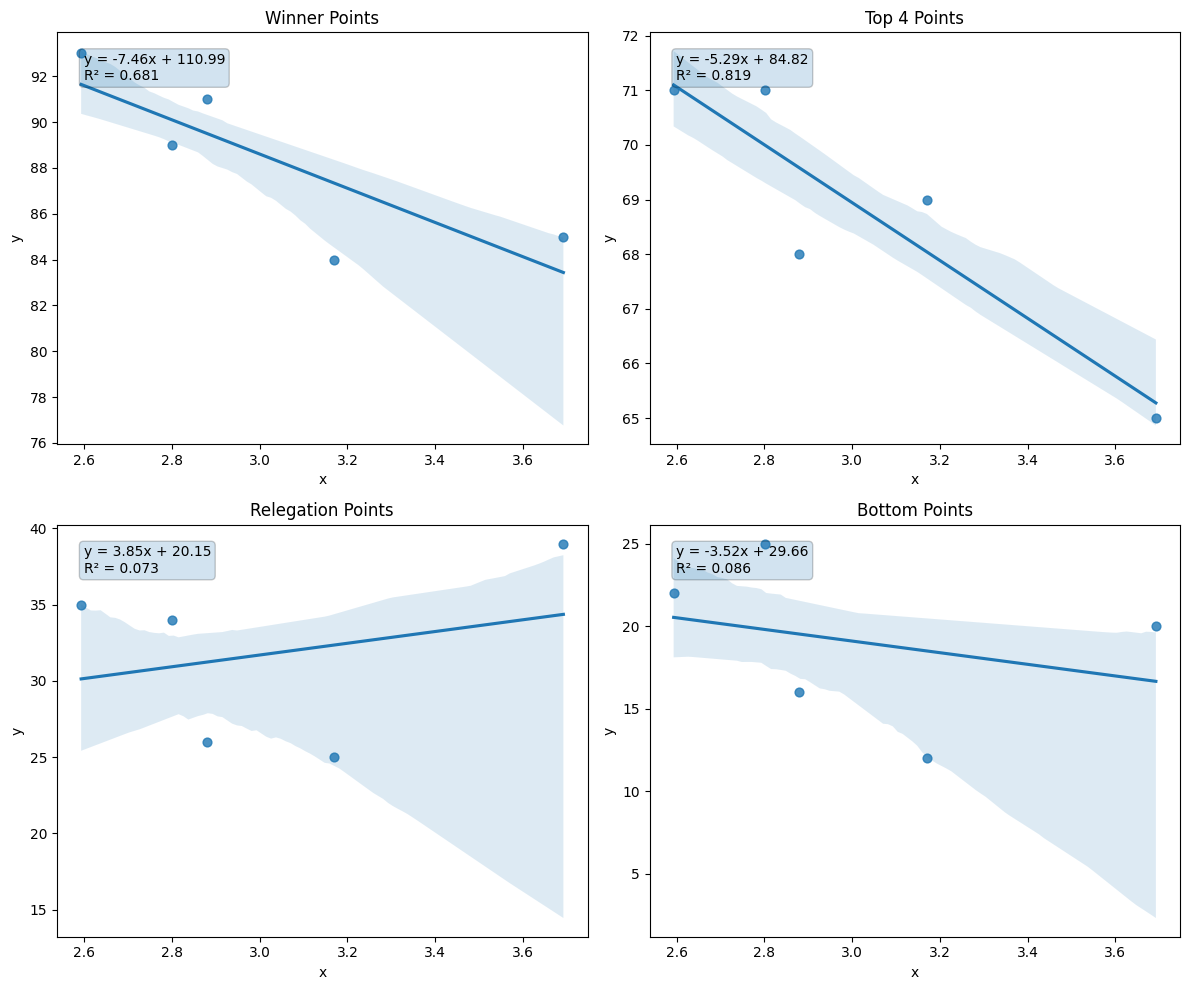

In [43]:
import seaborn as sns
from scipy.stats import linregress

datasets = [
    (pos_m, winner_p, "Winner Points"),
    (pos_m, top_4_p, "Top 4 Points"),
    (pos_m, relegation_p, "Relegation Points"),
    (pos_m, bottom_p, "Bottom Points"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (x, y, title) in zip(axes, datasets):

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    df_plot = pd.DataFrame({"x": x,"y": y})

    sns.regplot(data=df_plot,x="x",y="y",ci=68, ax=ax,scatter_kws={"s": 40})

    eq = (f"y = {slope:.2f}x + {intercept:.2f}\n" f"R² = {r_value**2:.3f}")

    ax.text(0.05,0.95,eq,
        transform=ax.transAxes,
        va="top",bbox=dict(boxstyle="round", alpha=0.2))

    ax.set_title(title)

plt.tight_layout()
plt.show()

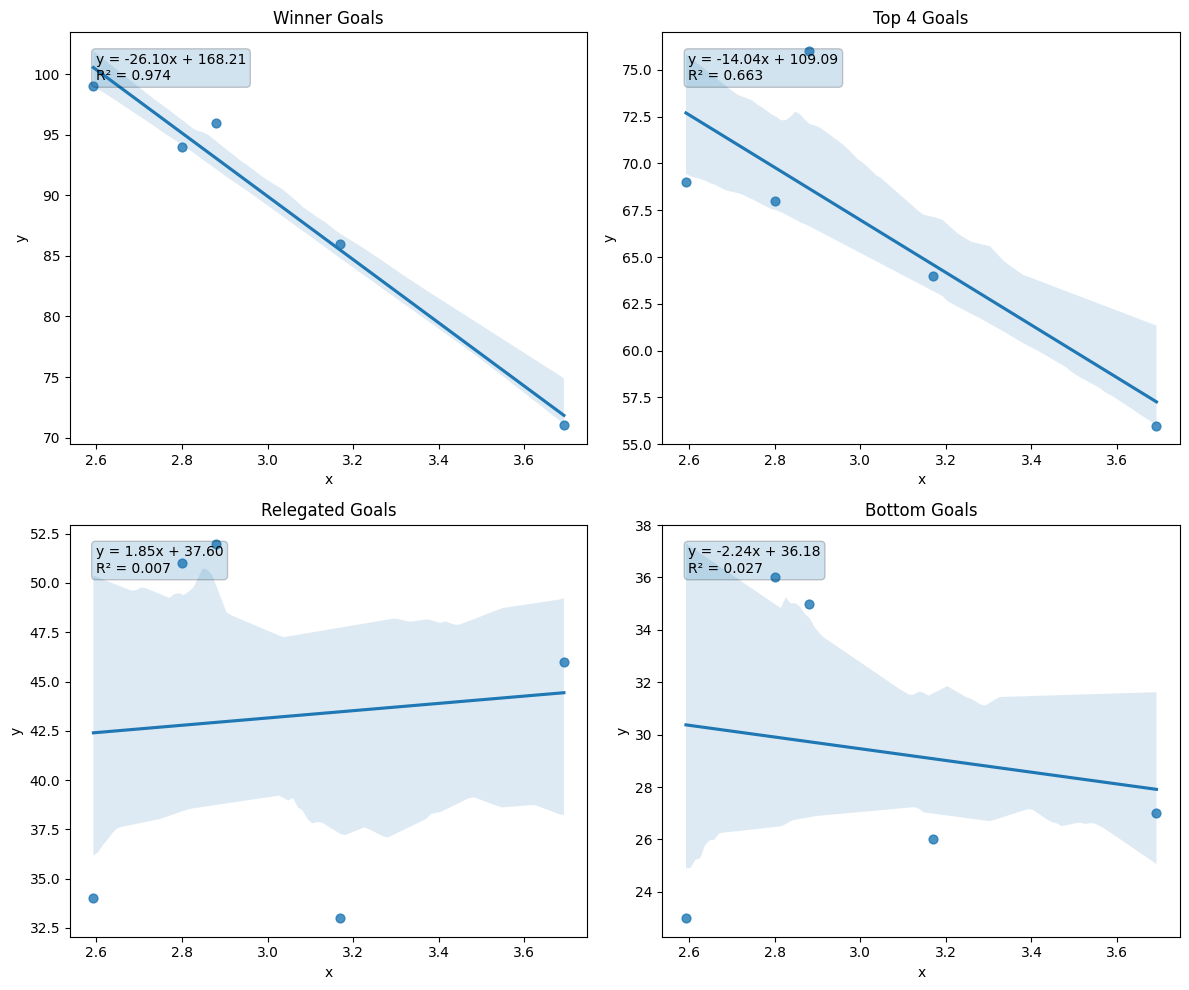

In [44]:
datasets = [(pos_m, winner_g, "Winner Goals"),
    (pos_m, top_4_g, "Top 4 Goals"),
    (pos_m, relegation_g, "Relegated Goals"),
    (pos_m, bottom_g, "Bottom Goals")]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (x, y, title) in zip(axes, datasets):

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    df_plot = pd.DataFrame({"x": x,"y": y})

    sns.regplot(data=df_plot,x="x",y="y",ci=68, ax=ax,scatter_kws={"s": 40})

    eq = (f"y = {slope:.2f}x + {intercept:.2f}\n" f"R² = {r_value**2:.3f}")

    ax.text(0.05,0.95,eq,
        transform=ax.transAxes,
        va="top",bbox=dict(boxstyle="round", alpha=0.2))

    ax.set_title(title)

plt.tight_layout()
plt.show()

Revisiting the home advantage extreme changes problem we faced with the simple BP model we calculated the home advantage on a weekly basis with the time decay feature, which means that every season's home advantage changes had effects from the previous values through the old likelihood values. Another way to calculate the home advantage is by not including the 2020,2021 seasons' data during training at all, this model's results named "peaky". The reason for the peaky approach is that the Covid data still affects the model further in the future ater the 2020,2021 season and so the home advantage evolves slower to the accurate value of the reality without the Covid effects.

In [45]:
home_adv_timedec_peacky = []
week_sim_peaky = []

for i in range(df['Season'].min()+1, df['Season'].max()+1):
  df_ex = df[(df['Season']<=i)*(df['Season']!=2020)*(df['Season']!=2021)][['HomeTeam','AwayTeam','HomeGoals','AwayGoals','Date']].copy()
  if (i!=2020) & (i!=2021):
    for j in range(0,40):
      df_ex2 = df_ex[df_ex['Date']<datetime(i,9,1)+timedelta(days=7*j)].copy()
      df_ex2['time_weights'] = np.exp(xi_optimal_DC*(df_ex2['Date']-df_ex2['Date'].max()).dt.days)

      goal_model_data = pd.concat([df_ex2[['HomeTeam','AwayTeam','HomeGoals','time_weights']].assign(home=1).rename(
            columns={'HomeTeam':'team', 'AwayTeam':'opponent','HomeGoals':'goals'}),
           df_ex2[['AwayTeam','HomeTeam','AwayGoals','time_weights']].assign(home=0).rename(
            columns={'AwayTeam':'team', 'HomeTeam':'opponent','AwayGoals':'goals'})])

      poisson_model = smf.glm(formula="goals ~ 0 + home + team + opponent", data=goal_model_data,freq_weights=goal_model_data['time_weights'],
                        family=sm.families.Poisson()).fit()


      home_adv_timedec_peacky.append(poisson_model.params.home)
      week_sim_peaky.append((i%2012-1)*52+j)

home_adv_timedec_peacky = np.array(home_adv_timedec_peacky)
week_sim_peaky = np.array(week_sim_peaky)

It is clear that the home advantage is much more stable with the time decay effect over the whole timespan of the data compared to the simple BP model, the new model is much more steady especially in the years after Covid limiting the min max range after 2020 to around [0.1,0.23] compared to [0.06,0.3]. A smoothed function is used for all the weekly home advantage value (with frac =0.2) since the value has large weekly fluctuations due to radomness. The model trained with the full dataset is adjusted very quikly as the Covid effects get smaller and agrees fully with the smoothed suction that ignored the 2020 and 2021 seasons' data.
The model that got trained without the 2020 and 2021 seasons data performed very poor at the start of the 2021 with the home advantage to start after Covid at an extremely large value. This is a result of the lack of also information about the team streangth for 2 years so this model needed two seasons to reach agreement with the full dataset model.

All the smoothed function have very small differences in the 2024 and 2025 home advantage values not overfitting the large decrease of the weekly home advantage at 2024. The values at the end of 2025 are resented and the two smoothed functions without the Covid data agree while the full dataset smoothed function shows slightly lower value due to the Covid seasons' effect in the training and "smoothing".

The best estimation seems to be the smoothed function without the Covid Data but based on the a model trained on the fuul dataset. The home advantage can be fixed sine it is approximated by a similar smooth function for such models with high accuracy, the home advantage of premier league for this model is 0.165.

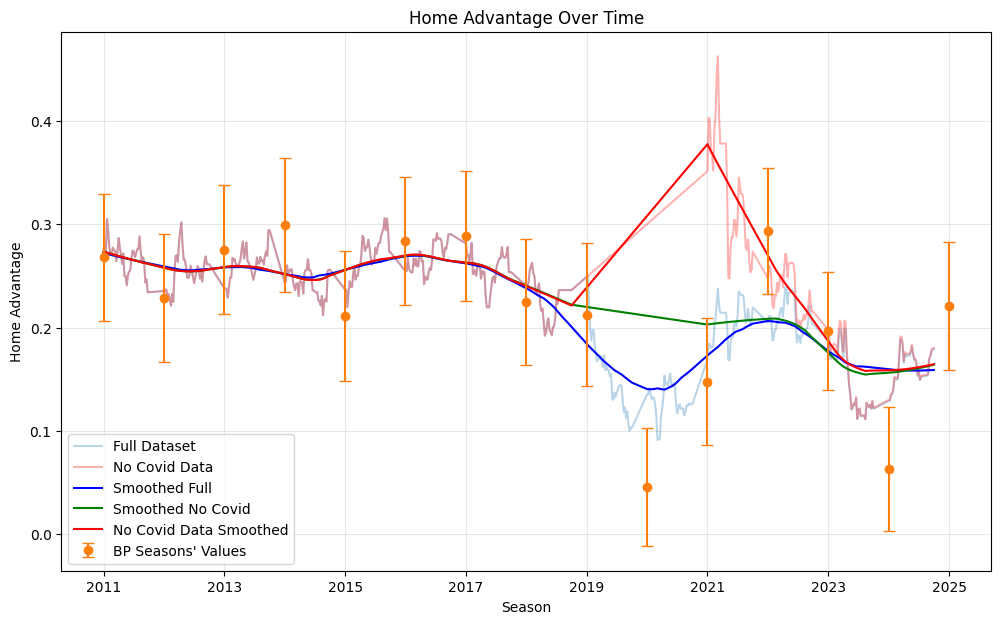

Full Dataset Smoothed: 0.159 , Full Dataset Smoothed without 2020,2021: 0.164 , Dataset without 2020,2021 Smoothed: 0.165


In [46]:
plt.figure(figsize = (12,7))
mask = (season_week_sim!=2020) & (season_week_sim!=2021)
plt.plot(week_sim,home_adv_timedec, alpha=0.3)
plt.plot(week_sim_peaky,home_adv_timedec_peacky, alpha=0.3,color = 'r')
plt.xlabel('Season')
plt.ylabel('Home Advantage')
plt.title('Home Advantage Over Time')

lowess = sm.nonparametric.lowess
smoothed = lowess(home_adv_timedec, week_sim, frac=0.2)
smoothed_adj = lowess(home_adv_timedec[mask], week_sim[mask], frac=0.2)
smoothed_peaky = lowess(home_adv_timedec_peacky, week_sim_peaky, frac=0.2)
plt.plot(smoothed[:,0], smoothed[:,1],color = 'b')
plt.plot(smoothed_adj[:,0], smoothed_adj[:,1],color = 'g')
plt.plot(smoothed_peaky[:,0], smoothed_peaky[:,1],color = 'r')

plt.errorbar(
    x=(season_sim%2011-1)*52,
    y=home_adv,
    yerr=home_std,
    fmt='o',
    capsize=4
)

plt.legend(['Full Dataset','No Covid Data','Smoothed Full','Smoothed No Covid','No Covid Data Smoothed','BP Seasons\' Values'])

plt.grid(alpha=0.3)
years = np.arange(2011, 2026, 2)
tick_positions = (years - 2012) * 52
plt.xticks(tick_positions, years)


plt.show()

print("Full Dataset Smoothed:",round(smoothed[-1,1],3),", Full Dataset Smoothed without 2020,2021:",round(smoothed_adj[-1,1],3),", Dataset without 2020,2021 Smoothed:",round(smoothed_peaky[-1,1],3))

For every model a big danger is the models' parameters autocorrelation being significant, a main assumption is that the model every time is getting trained its parameters are getting closer to their true value as more information is added and so they evolve as random walks. Practically there will be cases when the model overestimated a parameter due to a great result for a team but also also cases that underestimated one due to a terrible result that eventually cancels each other out showing that these cases happen at random. In case of autocorrelation throught it means that the model systematically changes the parameters more than it should within the same time window.

Below the teams whose parameters where collected and tranformed to their strength in the form of goal supremacy against the average team are tested for autocorrelation. They are all except Liverpool autocorrelated by a persistence lag of 2 weeks with 95% significance. The model is corrected to the opposite direction than two weeks before at a non random way. But there is no need for panic, this autocorrelation could be a result of the way we split the time steps of 7 days during the fittinf process and probably that is the cause. We selected the 1st of September ao each year which is a different day each time so it could lead to weeks of more games (sequentially a data week with a few and a week with many games) having more information and thus larger coefficients changes. For now it will be ignored but at the end of the notebook after the optimal model will have been selected this have to be tested again.

Similarly the home advantage is suffering from autocorrelation as well. The two weeks lag could also be explain by the way the data are splited but the 10 weeks one arises problems. This adds another reason for using a smoothed trend for the home advantage value rather than allowing to drift as a free parameter.

95% significance threshold: ±0.0828
Arsenal: Lag 2: -0.1674  <-- significant
Liverpool: No significant autocorrelation
Man City: Lag 2: -0.2295  <-- significant
Chelsea: Lag 2: -0.2045  <-- significant


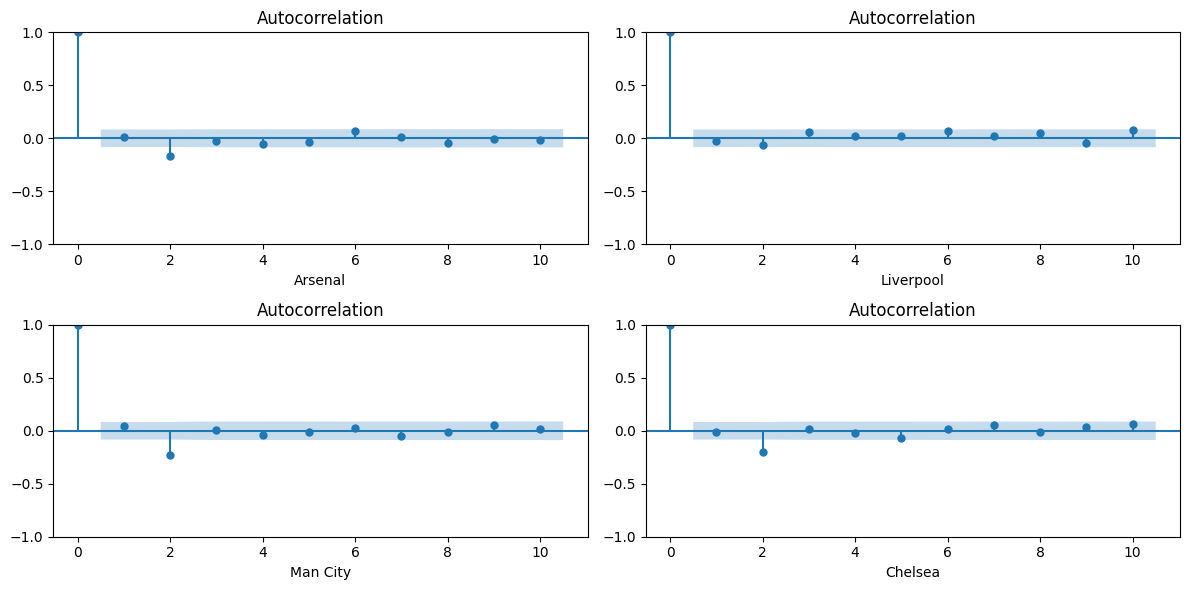

In [47]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

n = len(top_teams_strength[:,0])
threshold = 1.96 / np.sqrt(n)
print(f"95% significance threshold: ±{threshold:.4f}")

fig, axes = plt.subplots(2,2, figsize = (12,6))
axes = axes.flatten()

for i in range(0,4):
  k=1
  series = np.diff(top_teams_strength[:,i])
  acf_vals = acf(series, nlags=10)

  plot_acf(series, lags=10,ax=axes[i])
  axes[i].set_xlabel(selected_teams[i])

  for lag, value in enumerate(acf_vals[1:], start=1):
    if abs(value) > threshold:
      print(selected_teams[i] + ": " + f"Lag {lag}: {value:.4f}  <-- significant")
      k=0
  if k == 1:
    print(selected_teams[i] + ": " + "No significant autocorrelation")


plt.tight_layout()

Home Advantage: Lag 2: -0.0829  <-- significant
Home Advantage: Lag 10: -0.0961  <-- significant


<Figure size 800x400 with 0 Axes>

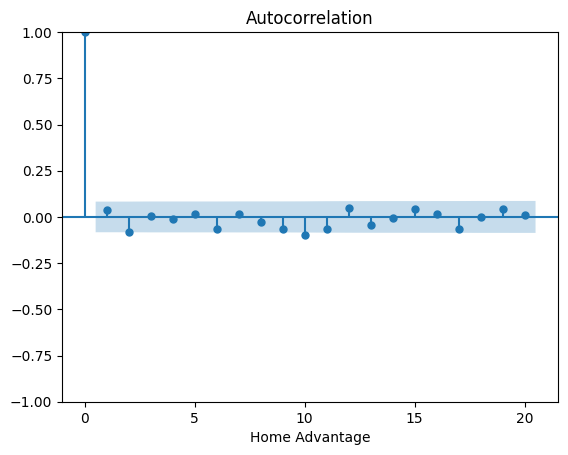

In [48]:

series = np.diff(home_adv_timedec)
acf_vals = acf(series, nlags=20)

plt.figure(figsize=(8,4))
plot_acf(series, lags=20)
plt.xlabel('Home Advantage')

for lag, value in enumerate(acf_vals[1:], start=1):
  if abs(value) > threshold:
    print("Home Advantage: " + f"Lag {lag}: {value:.4f}  <-- significant")


#### Score Matrix Correction:

Under the independent Poisson Bivariate model's assumption the scores of matches followed the distribution:

$$ P(X=x,Y=y) =  \frac{e^{-\lambda}\lambda^x}{x!} \frac{e^{-\mu}\mu^y}{y!}  =P(X=x) \cdot P(Y=y)$$

The goals of the home and away teams assumed to be independent but this contradicts the observations which show there is dependence in the low goals scores 0-0, 1-0, 0-1, 1-1. A dependence parameter ρ is introduced to modify the probabilities of low-scoring outcomes. The corrected probability becomes:

$$ P_{DC}(X=x,Y=y) =  \tau(x,y,λ,μ,ρ) \cdot P(X=x,Y=y) $$

where τ being the Dixon–Coles correction factor.The correction factor is defined as :

$$
\begin{array}{c|cccc}
\text{Home}\backslash\text{Away} & 0 & 1 & 2 & \cdots \\
\hline
0 & (1-\lambda\mu\rho)p_{00} & (1+\lambda\rho)p_{01} & p_{02} & \cdots \\
1 & (1+\mu\rho)p_{10} & (1-\rho)p_{11} & p_{12} & \cdots \\
2 & p_{20} & p_{21} & p_{22} & \cdots \\
\vdots & \vdots & \vdots & \vdots & \ddots
\end{array}
$$

The factor τ modifies only the four scorelines shown in the plot above by just multiplying the BP probability with the proper correction term while the rest of the scores remain unchanged.

The ρ factor is usually small within around [-0.15, 0.05] for different leagues, while it has three potential effects based on its range of values:

* ρ = 0 : reduces to the standard independent Bivariate Poisson model.
* ρ < 0 : increases the probability of draws and low-scoring matches (this is what have been observed in most cases with football data).
* ρ > 0: decreases the probability of low-scoring draws and increases some one-goal outcomes.


An important change in the model is that the LogLikelihood function is getting more complicated adding additional computational cost. For an observed match with score ((x,y)), the DC log-likelihood function is:

$$
\log L =  \log \tau(x,y,\lambda,\mu,\rho)
+ x\log\lambda -\lambda -\log(x!) + y\log\mu -\mu -\log(y!).
$$




In [51]:
def solve_parameters2(dataset, init_vals=None, constraints=None, options={'maxiter':100}, debug=False):

    teams = np.sort(pd.unique(pd.concat([dataset['HomeTeam'], dataset['AwayTeam']])))
    n_teams = len(teams)
    idx = {t: i for i, t in enumerate(teams)}

    home_idx = dataset['HomeTeam'].map(idx).values.astype(int)
    away_idx = dataset['AwayTeam'].map(idx).values.astype(int)
    hg = dataset['HomeGoals'].values.astype(int)
    ag = dataset['AwayGoals'].values.astype(int)
    w  = dataset['time_weights'].values if 'time_weights' in dataset else np.ones(len(dataset))

    lg_hg = gammaln(hg + 1)
    lg_ag = gammaln(ag + 1)
    m00 = (hg==0)&(ag==0)
    m01 = (hg==0)&(ag==1)
    m10 = (hg==1)&(ag==0)
    m11 = (hg==1)&(ag==1)

    if init_vals is None:
        init_vals = np.concatenate((np.random.uniform(0,1,n_teams),
                                    np.random.uniform(0,-1,n_teams),
                                    np.array([0.0, 1.0])))

    if constraints is None:
        constraints = [{'type':'eq','fun': lambda x, n=n_teams: np.sum(x[:n])}]

    def neg_log_likl(x):
        attack, defence = x[:n_teams], x[n_teams:2*n_teams]
        rho, home_adv = x[-2], x[-1]

        log_hx = attack[home_idx] + defence[away_idx] + home_adv
        log_ax = attack[away_idx] + defence[home_idx]
        hx, ax = np.exp(log_hx), np.exp(log_ax)

        t = np.ones(len(hg))
        t[m00] = 1 - hx[m00]*ax[m00]*rho
        t[m01] = 1 + hx[m01]*rho
        t[m10] = 1 + ax[m10]*rho
        t[m11] = 1 - rho
        t = np.maximum(t, 1e-10)

        ll = np.log(t) + (hg*log_hx - hx - lg_hg) + (ag*log_ax - ax - lg_ag)
        return -np.sum(w * ll)

    opt = minimize(neg_log_likl, init_vals, constraints=constraints, options=options)

    if debug:
        print(opt.message, opt.fun)

    params = dict(zip(['attack_'+t for t in teams], opt.x[:n_teams]))
    params.update(dict(zip(['defence_'+t for t in teams], opt.x[n_teams:2*n_teams])))
    params['rho'] = opt.x[-2]
    params['home_adv'] = opt.x[-1]
    return params

def dc_tau(hg, ag, home_exg, away_exg, rho):
    if hg == 0 and ag == 0:
        return 1 - home_exg * away_exg * rho
    elif hg == 0 and ag == 1:
        return 1 + home_exg * rho
    elif hg == 1 and ag == 0:
        return 1 + away_exg * rho
    elif hg == 1 and ag == 1:
        return 1 - rho
    else:
        return 1.0

def dc_score_matrix(home_exg, away_exg, rho, max_goals=10):
    m = np.outer(poisson.pmf(np.arange(max_goals+1), home_exg),
                 poisson.pmf(np.arange(max_goals+1), away_exg))
    for hg in range(2):
        for ag in range(2):
            m[hg, ag] *= dc_tau(hg, ag, home_exg, away_exg, rho)
    return m

def log_likl_eval_dc(params, teams, matches_results, matches_scores, matches):

    rho = params['rho']
    home_adv = params['home_adv']

    log_prob_sum = 0.0
    log_prob_scores_sum = 0.0
    n_skipped = 0

    for i, (home_team, away_team) in enumerate(matches):
        if ('attack_'+home_team not in params) or ('attack_'+away_team not in params):
            n_skipped += 1
            continue

        home_exg = np.exp(params['attack_'+home_team] + params['defence_'+away_team] + home_adv)
        away_exg = np.exp(params['attack_'+away_team] + params['defence_'+home_team])

        m = dc_score_matrix(home_exg, away_exg, rho)
        p_h = np.sum(np.tril(m, -1))
        p_d = np.sum(np.diag(m))
        p_a = np.sum(np.triu(m, 1))

        log_prob_sum += np.log(max(
            p_h * (matches_results[i] == 'H') +
            p_d * (matches_results[i] == 'D') +
            p_a * (matches_results[i] == 'A'), 1e-10))

        hg, ag = matches_scores[i]
        p = poisson.pmf(hg, home_exg) * poisson.pmf(ag, away_exg) * dc_tau(hg, ag, home_exg, away_exg, rho)
        log_prob_scores_sum += np.log(max(p, 1e-10))

    return log_prob_sum, log_prob_scores_sum, n_skipped

In [52]:
start = time.time()

xi = xi_optimal_DC
hl = np.log(2)/xi if xi > 0 else np.inf
window = int(8*hl) if np.isfinite(hl) else 10**6
print("xi =", xi, " half-life =", hl, " window (days) =", window)

no_rho_values = 9
rho_values = np.linspace(-0.2, 0.2, no_rho_values)
log_prob_resu_DC_rho   = np.zeros(no_rho_values)
log_prob_scores_DC_rho = np.zeros(no_rho_values)
total_skipped = 0

for i in range(2022, df['Season'].max()+1):
  print(i)
  df_ex = df[(df['Season']<=i)][['HomeTeam','AwayTeam','HomeGoals','AwayGoals','Date','FTR']].copy()
  for j in range(0,36):

    cutoff = datetime(i,10,1)+timedelta(days=7*j)
    df_slice_next_games = df_ex[(df_ex['Date']>cutoff) & (df_ex['Date']<cutoff+timedelta(days=7))].copy()
    games_to_be_played = list(df_slice_next_games[["HomeTeam", "AwayTeam"]].itertuples(index=False, name=None))

    if games_to_be_played != []:
      df_ex2 = df_ex[(df_ex['Date']<cutoff) & (df_ex['Date']>cutoff-timedelta(days=window))].copy()
      if len(df_ex2) == 0:
        continue
      df_ex2['time_weights'] = np.exp(xi*(df_ex2['Date']-df_ex2['Date'].max()).dt.days)
      n_teams = len(pd.unique(pd.concat([df_ex2['HomeTeam'], df_ex2['AwayTeam']])))

      constraints = [{'type': 'eq','fun': lambda x, n=n_teams: np.sum(x[:n])}]
      result = solve_parameters2(df_ex2, init_vals=None, constraints=constraints, options={'maxiter':100})

      for m, rho in enumerate(rho_values):
        params = dict(result); params['rho'] = rho
        log_prob_eval = log_likl_eval_dc(params = params, teams = df[(df['Season']==i)]['HomeTeam'].unique(), matches_results = df_slice_next_games["FTR"].values, matches_scores = df_slice_next_games[["HomeGoals", "AwayGoals"]].values, matches = games_to_be_played)
        log_prob_resu_DC_rho[m]   += log_prob_eval[0]
        log_prob_scores_DC_rho[m] += log_prob_eval[1]
      total_skipped += log_prob_eval[2]

end = time.time()
print("elapsed:", end-start, "s   matches skipped (unseen team):", total_skipped)

xi = 0.002631578947368421  half-life = 263.3959286127792  window (days) = 2107
2022
2023
2024
2025
elapsed: 227.55156421661377 s   matches skipped (unseen team): 0


best rho: -0.04999999999999999


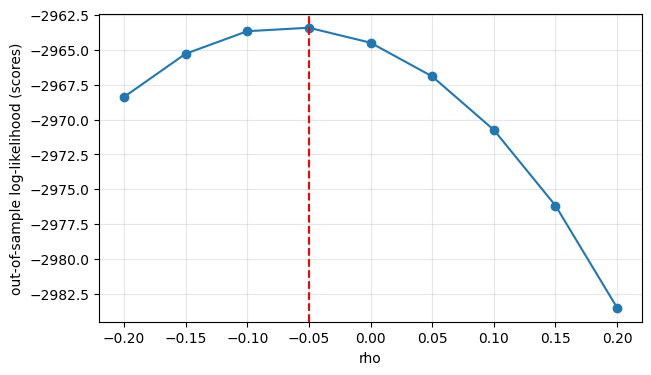

In [53]:
m_best = np.argmax(log_prob_scores_DC_rho)
print("best rho:", rho_values[m_best])

plt.figure(figsize=(7,4))
plt.plot(rho_values, log_prob_scores_DC_rho, marker='o')
plt.axvline(rho_values[m_best], ls='--', c='r')
plt.xlabel('rho'); plt.ylabel('out-of-sample log-likelihood (scores)'); plt.grid(alpha=0.3)
plt.show()

In [54]:
def to_nested(params):
    return {"attack":  {k[7:]: v for k, v in params.items() if k.startswith('attack_')},
            "defence": {k[8:]: v for k, v in params.items() if k.startswith('defence_')},
            "rho": params['rho'], "gamma": params['home_adv']}

b = to_nested(params)

Below the match result prediction can be estimated by the full Dixon-Coles model. Three type of cases are shown with the odds of extreme fav, slight fav and close game, in all cases the independent poisson distributions the draw probabillity is underestimated and this is the most important change of the Dixon-Coles empirical correction:

In [65]:
def dc_score_matrix_dict(home_team, away_team, model_dict, max_goals=10,independ = False):

    attack  = model_dict["attack"]
    defence = model_dict["defence"]
    if independ:
      rho = 0
    else:
      rho = model_dict["rho"]
    gamma = model_dict["gamma"]

    lambda_home = np.exp(attack[home_team] + defence[away_team] + gamma)
    lambda_away = np.exp(attack[away_team] + defence[home_team])

    m = np.outer(poisson.pmf(np.arange(max_goals+1), lambda_home),
                 poisson.pmf(np.arange(max_goals+1), lambda_away))

    m[0,0] *= 1 - lambda_home*lambda_away*rho
    m[0,1] *= 1 + lambda_home*rho
    m[1,0] *= 1 + lambda_away*rho
    m[1,1] *= 1 - rho

    return m/m.sum(), lambda_home, lambda_away


def predict_match_dc(home_team, away_team, model_dict, max_goals=10,independ = False):

    m, lambda_home, lambda_away = dc_score_matrix_dict(home_team, away_team, model_dict, max_goals, independ)

    p_home = np.sum(np.tril(m, -1))
    p_draw = np.sum(np.diag(m))
    p_away = np.sum(np.triu(m, 1))

    hg, ag = np.unravel_index(np.argmax(m), m.shape)

    return {'H': p_home, 'D': p_draw, 'A': p_away,
            'lambda_home': lambda_home, 'lambda_away': lambda_away,
            'most_likely_score': (int(hg), int(ag)),
            'p_most_likely': m[hg, ag],
            'matrix': m}


out = predict_match_dc('Arsenal', 'Chelsea', b)
print('Arsenal vs Chelsea DC:', out['H'].round(2), out['D'].round(2), out['A'].round(2), out['most_likely_score'])
out = predict_match_dc('Arsenal', 'Chelsea', b,independ = True)
print('Arsenal vs Chelsea Independent:', out['H'].round(2), out['D'].round(2), out['A'].round(2), out['most_likely_score'])

out = predict_match_dc('Man City', 'Burnley', b)
print('Man City vs Burnley:',out['H'].round(2), out['D'].round(2), out['A'].round(2), out['most_likely_score'])
out = predict_match_dc('Man City', 'Burnley', b,independ = True)
print('Man City vs Burnley Independent:', out['H'].round(2), out['D'].round(2), out['A'].round(2), out['most_likely_score'])

out = predict_match_dc('Everton', 'Aston Villa', b)
print('Everton vs Aston Villa:',out['H'].round(2), out['D'].round(2), out['A'].round(2), out['most_likely_score'])
out = predict_match_dc('Everton', 'Aston Villa', b,independ = True)
print('Everton vs Aston Villa Independent:', out['H'].round(2), out['D'].round(2), out['A'].round(2), out['most_likely_score'])

Arsenal vs Chelsea DC: 0.66 0.18 0.17 (1, 0)
Arsenal vs Chelsea Independent: 0.64 0.22 0.15 (1, 0)
Man City vs Burnley: 0.86 0.08 0.06 (3, 0)
Man City vs Burnley Independent: 0.85 0.1 0.05 (3, 0)
Everton vs Aston Villa: 0.4 0.22 0.39 (1, 0)
Everton vs Aston Villa Independent: 0.37 0.27 0.36 (1, 1)


## Negative Binomial:

Under the Poisson assumption the mean and the variance of the observations have to be the same but in cases of many scorelines with extreme goals' number this equallity does not hold and overdispersion is observed. For this case the Negative Binomial distribution is a better model selection.

The Negative Binomial model is an extension of the Poisson regression that allows the variance to be larger than the mean value by a free parameter $\alpha$ :


$$ y_{i} \sim NB(μ_{i}, α) $$

where $\mu_i$ is the conditional mean and $\alpha > 0$ is the overdispersion parameter.

The mean and variance of the NEgative Binomial distribution are:

$$
\mathbb{E}[y_i] = \mu_i \\
\text{Var}(y_i) = \mu_i + \alpha \mu_i^2
$$

This allows the variance to exceed the mean, unlike the Poisson model, while for $\alpha = 0 $ the NB model tends to Poisson model and the larger the value of $\alpha$ gets the less predictability a model has.

The NB distribution is a binomial type of distribution that covers the calculation of the probability of observing r sucesses and k fails. The parameters of the NB are the probability of success $p$ and number of successes $r$ with pmf:

$$ P(X = k) = \binom{k + r - 1}{k} p^r (1-p)^k $$

This mathematical representation is not helpfull for using the NB for calculating the teams' parameters through MLE.

A different way to approach the NB model is as a Poisson-Gamma mixture distribution. The poisson parameter $\lambda$ follows a Gamma distribution, which will be shown in the ExG based models' notebook, meaning that the ExG is following a Gamma distribution which affects the poisson variance further by introducing heterogeneity in the Poisson rate. The exact model is :

$$
y_i \mid \lambda_i \sim \text{Poisson}(\lambda_i)
$$

$$
\lambda_i \sim \text{Gamma}\left(\frac{1}{\alpha}, \alpha \mu_i\right)
$$

The likelihood for observation ($y_i$) is:

$$
\log L_i = \log \Gamma(y_i + r) - \log \Gamma(r) - \log (y_i!)
+ r \log \left(\frac{r}{r + \mu_i}\right)
+ y_i \log \left(\frac{\mu_i}{r + \mu_i}\right)
$$

where $r = \frac{1}{\alpha}$.

The $\alpha$ parameter is expected to be small since the Poisson distribution fits well the match scores so a reasonable range would be [0.1,0.3].

In [66]:
no_xi_values = 10
no_alpha_values = 3
xi_values = np.linspace(0,0.01,no_xi_values)
alpha_values = np.linspace(0.05,0.15,no_alpha_values)
log_prob_resu_xi_NGB = np.zeros((no_xi_values,no_alpha_values))
log_prob_scores_xi_NGB = np.zeros((no_xi_values,no_alpha_values))
m = 0
for k in xi_values:
  n=0
  for l in alpha_values:
    for i in range(2022, df['Season'].max()+1):
      df_ex = df[(df['Season']<=i)][['HomeTeam','AwayTeam','HomeGoals','AwayGoals','Date','FTR']].copy()
      for j in range(0,45):

        df_slice_next_games = df_ex[(df_ex['Date']>datetime(i,9,1)+timedelta(days=7*j)) & (df_ex['Date']<datetime(i,9,1)+timedelta(days=7*j+7))].copy()
        games_to_be_played = list(df_slice_next_games[["HomeTeam", "AwayTeam"]].itertuples(index=False, name=None))

        if games_to_be_played != []:
          df_ex2 = df_ex[df_ex['Date']<datetime(i,9,1)+timedelta(days=7*j)].copy()
          df_ex2['time_weights'] = np.exp(k*(df_ex2['Date']-df_ex2['Date'].max()).dt.days)

          goal_model_data = pd.concat([df_ex2[['HomeTeam','AwayTeam','HomeGoals','time_weights']].assign(home=1).rename(
              columns={'HomeTeam':'team', 'AwayTeam':'opponent','HomeGoals':'goals'}),
          df_ex2[['AwayTeam','HomeTeam','AwayGoals','time_weights']].assign(home=0).rename(
              columns={'AwayTeam':'team', 'HomeTeam':'opponent','AwayGoals':'goals'})])

          poisson_model_time_dec = smf.glm(formula="goals ~ 0 + home + team + opponent", data=goal_model_data,freq_weights=goal_model_data['time_weights'],
                                         family=sm.families.NegativeBinomial(alpha = l)).fit()

          log_prob_eval = log_likl_eval(poisson_model_time_dec,df_slice_next_games["FTR"].values,matches_scores = df_slice_next_games[["HomeGoals", "AwayGoals"]].values,matches = games_to_be_played)
          log_prob_resu_xi_NGB[m,n] += log_prob_eval[0]
          log_prob_scores_xi_NGB[m,n] += log_prob_eval[1]
    n += 1
  m += 1

Below the optimal values of α and ξ are presented based on the score matrix likelihood. An interesting observation is that the parameter alpha has no noticable effect in the loglikelihood as long as it is small ($\alpha <0.5$).

In [67]:
max_likel_NB_SC = -100000000000
optimal_NGB_alpha = 0
optimal_NGB_xi = 0
max_likel_NB_RESU = 0

for i in range(no_xi_values):
  for j in range(no_alpha_values):
    if max_likel_NB_SC<log_prob_scores_xi_NGB[i,j]:
      max_likel_NB_SC = log_prob_scores_xi_NGB[i,j]
      optimal_NGB_alpha = alpha_values[j]
      optimal_NGB_xi = xi_values[i]
      max_likel_NB_RESU = log_prob_resu_xi_NGB[i,j]


print("Optimal alpha Value:",optimal_NGB_alpha,"Optimal ξ Value:",np.round(optimal_NGB_xi,5),"Maximum Loglikelihood Value:",np.round(max_likel_NB_SC,2))

Optimal alpha Value: 0.15 Optimal ξ Value: 0.00222 Maximum Loglikelihood Value: -3723.55


Best ξ value based on scores' Likelihood: 0.00222


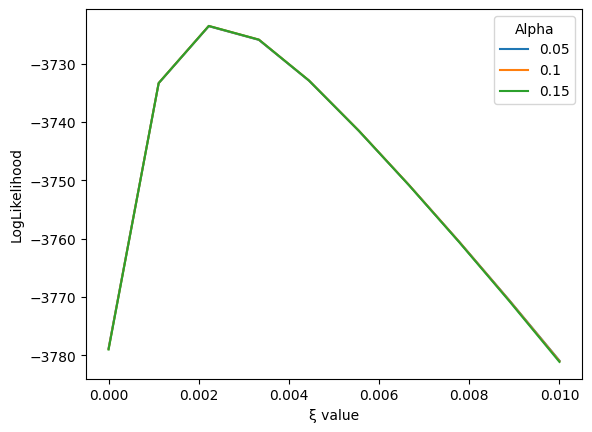

In [68]:
for i in range(0,no_alpha_values):
  plt.plot(xi_values,log_prob_scores_xi_NGB[:,i],label = str(alpha_values[i]))

plt.xlabel('ξ value')
plt.ylabel('LogLikelihood')
plt.legend(title = 'Alpha')

print("Best ξ value based on scores' Likelihood:",np.round(optimal_NGB_xi,5))

## Models' Comparison:

The three models based on match goals explored are the independent poisson distributions, the Dixon-Coles and the negative binomial distributions one all with optimal time weights. For choosing the best model the following metrics are used:

- The mean negative log-probability assigned to the scoreline that actually
occurred:

$$
\mathcal{L}^{M}_{\text{score}}
= -\frac{1}{N}\sum_{i=1}^{N} \log P^{M}_{i}(h_i, a_i).
$$


- The result log-loss is essentially the same quantity restricted to the three-way outcome is also used:

$$
\mathcal{L}^{M}_{\text{result}}
= -\frac{1}{N}\sum_{i=1}^{N} \log p^{M}_{i, y_i}.
$$

- The multi-category Brier score, ignoring the ordering:

$$
\mathrm{BS}^{M}
= \frac{1}{N}\sum_{i=1}^{N}
\sum_{c \in \{\mathrm{H},\mathrm{D},\mathrm{A}\}}
\left( p^{M}_{i,c} - \mathbf{1}\{y_i = c\} \right)^{2}.
$$


All these metrics are calculated out-of-sample with the models being updated weekly and predicting only the games of the next week.

In [81]:
xi = xi_optimal_DC
xi_ngb = optimal_NGB_xi
rho_best = rho_values[m_best]
alpha_best = optimal_NGB_alpha
MAXG = 10
START_MONTH, START_DAY, N_WEEKS = 10, 1, 45
USE_WINDOW = False
window = int(8*np.log(2)/xi) if xi > 0 else 10**6

def poisson_matrix(mu_h, mu_a, rho=0.0):
    m = np.outer(poisson.pmf(np.arange(MAXG+1), mu_h),
                 poisson.pmf(np.arange(MAXG+1), mu_a))
    if rho != 0.0:
        m[0,0] *= 1 - mu_h*mu_a*rho
        m[0,1] *= 1 + mu_h*rho
        m[1,0] *= 1 + mu_a*rho
        m[1,1] *= 1 - rho
    return m/m.sum()

def nb_matrix(mu_h, mu_a, alpha):
    r = 1.0/alpha
    ph = nbinom.pmf(np.arange(MAXG+1), r, r/(r+mu_h))
    pa = nbinom.pmf(np.arange(MAXG+1), r, r/(r+mu_a))
    m = np.outer(ph, pa)
    return m/m.sum()

def matrix_metrics(m, res, hg, ag):
    p_h = np.sum(np.tril(m,-1)); p_d = np.sum(np.diag(m)); p_a = np.sum(np.triu(m,1))
    p_res = {'H':p_h, 'D':p_d, 'A':p_a}[res]
    p_score = m[hg, ag] if (hg <= MAXG and ag <= MAXG) else 1e-12
    pred_res = ['H','D','A'][int(np.argmax([p_h,p_d,p_a]))]
    ph_i, pa_i = np.unravel_index(np.argmax(m), m.shape)

    cum_p = np.cumsum([p_h,p_d,p_a]); cum_o = np.cumsum([res=='H', res=='D', res=='A'])
    brier = np.sum((np.array([p_h,p_d,p_a]) - np.array([res=='H',res=='D',res=='A'],float))**2)
    return dict(p_res=max(p_res,1e-12), p_score=max(p_score,1e-12), brier=brier)

start = time.time()
records = []
n_skipped = 0

for i in range(2022, df['Season'].max()+1):
  print(i)
  df_ex = df[(df['Season']<=i)][['HomeTeam','AwayTeam','HomeGoals','AwayGoals','Date','FTR']].copy()
  for j in range(0, N_WEEKS):

    cutoff = datetime(i,START_MONTH,START_DAY)+timedelta(days=7*j)
    nxt = df_ex[(df_ex['Date']>cutoff) & (df_ex['Date']<cutoff+timedelta(days=7))].copy()
    if len(nxt) == 0:
      continue

    df_ex2 = df_ex[df_ex['Date']<cutoff].copy()
    if USE_WINDOW:
      df_ex2 = df_ex2[df_ex2['Date']>cutoff-timedelta(days=window)]
    if len(df_ex2) < 50:
      continue
    df_ex2['time_weights'] = np.exp(xi*(df_ex2['Date']-df_ex2['Date'].max()).dt.days)
    df_ex3 = df_ex2.copy()
    df_ex3['time_weights'] = np.exp(xi_ngb*(df_ex3['Date']-df_ex3['Date'].max()).dt.days)

    seen = set(pd.unique(pd.concat([df_ex2['HomeTeam'], df_ex2['AwayTeam']])))
    nxt_ok = nxt[nxt['HomeTeam'].isin(seen) & nxt['AwayTeam'].isin(seen)].copy()
    n_skipped += len(nxt) - len(nxt_ok)
    if len(nxt_ok) == 0:
      continue

    n_teams = len(seen)

    cons_sum = {'type':'eq','fun': lambda x, n=n_teams: np.sum(x[:n])}
    par_dc = solve_parameters2(df_ex2, constraints=[cons_sum, {'type':'eq','fun': lambda x, r=rho_best: x[-2]-r}], options={'maxiter':100})
    par_pois = solve_parameters2(df_ex2, constraints=[cons_sum, {'type':'eq','fun': lambda x: x[-2]}], options={'maxiter':100})

    gm = pd.concat([df_ex3[['HomeTeam','AwayTeam','HomeGoals','time_weights']].assign(home=1).rename(
            columns={'HomeTeam':'team','AwayTeam':'opponent','HomeGoals':'goals'}),
        df_ex3[['AwayTeam','HomeTeam','AwayGoals','time_weights']].assign(home=0).rename(
            columns={'AwayTeam':'team','HomeTeam':'opponent','AwayGoals':'goals'})])
    ngb = smf.glm(formula="goals ~ 0 + home + team + opponent", data=gm,
                  freq_weights=gm['time_weights'],
                  family=sm.families.NegativeBinomial(alpha=alpha_best)).fit()

    for _, row in nxt_ok.iterrows():
      h, a, hg, ag, res = row['HomeTeam'], row['AwayTeam'], int(row['HomeGoals']), int(row['AwayGoals']), row['FTR']

      mu_dc_h = np.exp(par_dc['attack_'+h] + par_dc['defence_'+a] + par_dc['home_adv'])
      mu_dc_a = np.exp(par_dc['attack_'+a] + par_dc['defence_'+h])
      mu_po_h = np.exp(par_pois['attack_'+h] + par_pois['defence_'+a] + par_pois['home_adv'])
      mu_po_a = np.exp(par_pois['attack_'+a] + par_pois['defence_'+h])
      mu_nb_h = ngb.predict(pd.DataFrame({'team':[h],'opponent':[a],'home':[1]}))[0]
      mu_nb_a = ngb.predict(pd.DataFrame({'team':[a],'opponent':[h],'home':[0]}))[0]

      mats = {'DixonColes': poisson_matrix(mu_dc_h, mu_dc_a, rho_best),
              'Poisson': poisson_matrix(mu_po_h, mu_po_a, 0.0),
              'NegBinomial': nb_matrix(mu_nb_h, mu_nb_a, alpha_best)}

      for name, mat in mats.items():
        rec = matrix_metrics(mat, res, hg, ag)
        rec.update(model=name, season=i, home=h, away=a, hg=hg, ag=ag,
                   match_id=str(row['Date'])+h+a)
        records.append(rec)

res_df = pd.DataFrame(records)
print("elapsed:", time.time()-start, "s  matches skipped:", n_skipped,
      " matches scored:", res_df['match_id'].nunique())

summary = res_df.groupby('model').agg(
    n = ('p_res','size'),
    logloss_result = ('p_res', lambda s: -np.mean(np.log(s))),
    logloss_score = ('p_score', lambda s: -np.mean(np.log(s))),
    brier = ('brier','mean')).sort_values('logloss_score')

print(summary.round(4))

2022
2023
2024
2025
elapsed: 1704.34779214859 s  matches skipped: 0  matches scored: 985
               n  logloss_result  logloss_score   brier
model                                                  
DixonColes   985          0.9803         3.0086  0.5848
Poisson      985          0.9807         3.0095  0.5849
NegBinomial  985          0.9839         3.0354  0.5865


As it can be seen the Dixon-Coles model performed the best but the difference with the independent poisson distributions is very small. The negative binomial distribution model scored the worst of the three of them in all metrics.

Because every model is scored on an identical fixture set, models $A$ and $B$
are compared through the per-match log-score differences

$$
d_i = \log P^{A}_{i}(h_i,a_i) - \log P^{B}_{i}(h_i,a_i),
\qquad
\bar{d} = \frac{1}{N}\sum_{i=1}^{N} d_i .
$$

With $s_d$ the sample standard deviation of $\{d_i\}$, the test statistic is

$$
t = \frac{\bar{d}}{s_d / \sqrt{N}},
$$

a Diebold–Mariano statistic for equal predictive accuracy, with
$H_0 : \mathbb{E}[d_i] = 0$. Pairing removes the between-match variance,
which dominates the between-model variance here, so $t$ is far more
sensitive than comparing the aggregate log-losses directly.

As it can be seen below the Negative Binomial distributions model is significantly worst compared to the Dixon-Coles model while the difference between the Dixon-Coles and the independent Poisson distributions one is not statistically significant. Given that the purpose of the modeling here is the out-of-sample prediction even a non highly significant difference is still preffered so the Dixon-Coles model is the best choice for these data.

In [83]:
metrics = [('logloss_score', 'score log-loss', -np.log(res_df['p_score'])),
           ('logloss_result', 'result log-loss', -np.log(res_df['p_res'])),
           ('brier', 'Brier score', res_df['brier'])]

loss_df = res_df[['match_id','model']].copy()
for col, lab, vals in metrics:
    loss_df[col] = vals.values

for col, lab, _ in metrics:
    piv = loss_df.pivot_table(index='match_id', columns='model', values=col)
    means = piv.mean().sort_values()
    best = means.index[0]
    print("\n%s  (lower better)   best = %s  [%0.4f]" % (lab, best, means[best]))
    for other in means.index[1:]:
        d = (piv[other] - piv[best]).dropna()
        se = d.std()/np.sqrt(len(d))
        print("  vs %-12s mean %+0.4f   se %0.4f   t %+0.2f" % (other, d.mean(), se, d.mean()/se))


score log-loss  (lower better)   best = DixonColes  [3.0086]
  vs Poisson      mean +0.0009   se 0.0012   t +0.77
  vs NegBinomial  mean +0.0268   se 0.0057   t +4.66

result log-loss  (lower better)   best = DixonColes  [0.9803]
  vs Poisson      mean +0.0004   se 0.0008   t +0.43
  vs NegBinomial  mean +0.0036   se 0.0020   t +1.80

Brier score  (lower better)   best = DixonColes  [0.5848]
  vs Poisson      mean +0.0001   se 0.0004   t +0.26
  vs NegBinomial  mean +0.0017   se 0.0011   t +1.55


There is no point into comparing this model with the market since the difference is expected to be very large. These models are based on goals which are extremely noisy and can be very misleading especially at the start of a season. Lucky teams and unlucky teams can exist for a certain number of games making parameters' estimations with large errors, models based on the ExG metric can be far more accurate. Also lot of information is missing such as players' information, cards, penalties, corners, free kicks, transfers, motivation and teams' playing extra matches in Europe. In the next projects the addition of information can be showm with more accurate estimations even beyond just the goal related markets.